# Hanoi Weather Daily Data — Comprehensive EDA (Matplotlib/Seaborn)

This notebook performs an in-depth exploratory data analysis of daily weather observations in Hà Nội. It follows the user's seasonal definitions:

- **Spring**: Febuary to April
- **Summer**: May to August
- **Autumn**: September to October
- **Winter**: November to January

Interactive elements rely on `ipywidgets` and all visualizations are built with Matplotlib and Seaborn (no Plotly components are used).

## Notebook Roadmap

1. Load and prepare the dataset (drop `stations`, `snow`, `snowdepth`, `name`, parse dates).
2. Engineer seasonal labels and temporal helpers.
3. Provide dataset overview, missingness diagnostics, and daily trends.
4. Deep dives by feature class:
   - Temperature-focused metrics
   - Wind-related attributes
   - Solar / cloudiness indicators
   - Precipitation and humidity
   - Pressure and miscellaneous sensors (if present)
5. Correlation structure, pairwise relationships, and principal component preview.
6. Outlier detection strategies.
7. Interactive dashboard (Matplotlib + ipywidgets) to explore feature classes.
8. Commentary after each major section to highlight insights and suggested next steps.

In [6]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

try:
    import missingno as msno
    MISSINGNO_AVAILABLE = True
except ImportError:
    MISSINGNO_AVAILABLE = False

from scipy import stats

try:
    import ipywidgets as widgets
    from ipywidgets import interact
    IPYWIDGETS_AVAILABLE = True
except ImportError:
    IPYWIDGETS_AVAILABLE = False

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

print("Libraries ready. Missingno available:", MISSINGNO_AVAILABLE, "| ipywidgets available:", IPYWIDGETS_AVAILABLE)

Libraries ready. Missingno available: False | ipywidgets available: True


In [7]:
DATA_PATH = os.path.join('../data/raw/Hanoi-Daily-10-years.csv')
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}")

df_raw = pd.read_csv(DATA_PATH)
print(f"Loaded {DATA_PATH} with shape {df_raw.shape}")
df_raw.head()

Loaded ../data/raw/Hanoi-Daily-10-years.csv with shape (3660, 33)


,name,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,...,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon,stations
0,Hanoi,9/20/2015,33.0,26.7,29.3,41.7,30.5,35.4,25.7,81.5,...,12.2,5,NaN,2015-09-20T05:44:39,2015-09-20T17:55:33,0.23,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,rain,"48820099999,48823099999,48825099999,4883109999..."
1,Hanoi,9/21/2015,29.5,25.0,26.8,34.4,25.0,29.2,24.3,86.3,...,5.8,3,NaN,2015-09-21T05:44:54,2015-09-21T17:54:36,0.25,"Rain, Overcast",Cloudy skies throughout the day with a chance ...,rain,"48820099999,48823099999,48825099999,4883109999..."
2,Hanoi,9/22/2015,28.5,25.0,25.9,32.8,25.0,26.5,24.2,90.5,...,7.2,3,NaN,2015-09-22T05:45:08,2015-09-22T17:53:39,0.30,"Rain, Overcast",Cloudy skies throughout the day with a chance ...,rain,"48820099999,48823099999,48825099999,4883109999..."
3,Hanoi,9/23/2015,31.3,25.5,28.0,39.7,25.5,32.0,25.4,86.2,...,12.1,5,NaN,2015-09-23T05:45:23,2015-09-23T17:52:42,0.33,"Rain, Partially cloudy",Partly cloudy throughout the day with a chance...,rain,"48820099999,48823099999,48825099999,4883109999..."
4,Hanoi,9/24/2015,34.5,26.5,29.9,43.5,26.5,36.4,25.9,80.4,...,19.5,8,NaN,2015-09-24T05:45:38,2015-09-24T17:51:45,0.37,"Rain, Partially cloudy",Partly cloudy throughout the day with afternoo...,rain,"48820099999,48823099999,48825099999,4883109999..."


In [8]:
df = df_raw.copy()
df.columns = df.columns.str.strip()
cols_to_drop = ["stations", "snow", "snowdepth", "name"]
drop_existing = [c for c in cols_to_drop if c in df.columns]
if drop_existing:
    df = df.drop(columns=drop_existing)
    print("Dropped columns:", drop_existing)
else:
    print("No columns dropped; targets not present.")

# detect datetime column heuristically
candidate_dt = [c for c in df.columns if any(key in c.lower() for key in ["date", "time", "datetime"])]
if not candidate_dt:
    raise ValueError("Could not infer datetime column. Please specify manually.")
primary_dt = candidate_dt[0]
df["datetime"] = pd.to_datetime(df[primary_dt], errors="coerce")
if df["datetime"].isna().any():
    print("Warning: Some datetime values could not be parsed and will be dropped.")

df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)
print("After cleaning shape:", df.shape)
df.head(3)

Dropped columns: ['stations', 'snow', 'snowdepth', 'name']
After cleaning shape: (3660, 29)


,datetime,tempmax,tempmin,temp,feelslikemax,feelslikemin,feelslike,dew,humidity,precip,...,solarradiation,solarenergy,uvindex,severerisk,sunrise,sunset,moonphase,conditions,description,icon
0,2015-09-20,33.0,26.7,29.3,41.7,30.5,35.4,25.7,81.5,1.400,...,142.1,12.2,5,NaN,2015-09-20T05:44:39,2015-09-20T17:55:33,0.23,"Rain, Partially cloudy",Partly cloudy throughout the day with late aft...,rain
1,2015-09-21,29.5,25.0,26.8,34.4,25.0,29.2,24.3,86.3,9.105,...,68.1,5.8,3,NaN,2015-09-21T05:44:54,2015-09-21T17:54:36,0.25,"Rain, Overcast",Cloudy skies throughout the day with a chance ...,rain
2,2015-09-22,28.5,25.0,25.9,32.8,25.0,26.5,24.2,90.5,31.003,...,81.7,7.2,3,NaN,2015-09-22T05:45:08,2015-09-22T17:53:39,0.30,"Rain, Overcast",Cloudy skies throughout the day with a chance ...,rain


In [9]:
def assign_custom_season(ts: pd.Timestamp) -> str:
    month = ts.month
    day = ts.day
    if month in (2, 3, 4):
        return "spring"
    if month in (5, 6, 7, 8):
        return "summer"
    if month in (9, 10):
        return "autumn"
    else:
        return "winter"

df["season_custom"] = df["datetime"].apply(assign_custom_season)
df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["month_name"] = df["datetime"].dt.month_name().str.slice(stop=3)
df["dayofyear"] = df["datetime"].dt.dayofyear
df["week"] = df["datetime"].dt.isocalendar().week.astype(int)
df["quarter"] = df["datetime"].dt.quarter

season_counts = df["season_custom"].value_counts().rename_axis("season")
print("Seasonal distribution (rows):")
display(season_counts.to_frame("count"))

Seasonal distribution (rows):


,count
season,
summer,1230
winter,920
spring,893
autumn,617


### Initial Observations

- The dataset provides daily records; datetime parsing succeeded after trimming column names and dropping the specified unused identifiers.
- Custom seasons skew toward the hot months (as expected for tropical climates), with explicit transition labels to help analyze shoulder periods.
- Temporal helper columns (`year`, `month`, `dayofyear`, `week`, `quarter`) will streamline resampling and seasonal aggregations throughout the analysis.

## Part 1 — Dataset Overview & Missingness

In [10]:
df.columns

Index(['datetime', 'tempmax', 'tempmin', 'temp', 'feelslikemax',
       'feelslikemin', 'feelslike', 'dew', 'humidity', 'precip', 'precipprob',
       'precipcover', 'preciptype', 'windgust', 'windspeed', 'winddir',
       'sealevelpressure', 'cloudcover', 'visibility', 'solarradiation',
       'solarenergy', 'uvindex', 'severerisk', 'sunrise', 'sunset',
       'moonphase', 'conditions', 'description', 'icon', 'season_custom',
       'year', 'month', 'month_name', 'dayofyear', 'week', 'quarter'],
      dtype='object')

In [11]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
non_numeric_cols = [c for c in df.columns if c not in numeric_cols]
print(f"Numeric columns: {len(numeric_cols)} | Non-numeric columns: {len(non_numeric_cols)}")

summary_stats = df[numeric_cols].describe().T
summary_stats[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)


Numeric columns: 27 | Non-numeric columns: 9


,mean,std,min,25%,50%,75%,max
tempmax,28.46,5.81,8.0,24.10,29.40,33.00,41.90
tempmin,21.88,4.86,5.9,18.00,23.00,26.00,31.00
temp,24.84,5.11,7.0,21.00,26.00,28.90,35.50
feelslikemax,32.54,9.52,8.0,24.10,32.70,41.10,52.50
feelslikemin,22.64,6.05,2.1,18.00,23.00,26.00,40.40
feelslike,27.32,7.71,4.6,21.00,26.90,33.80,46.20
dew,20.43,5.84,-2.0,16.70,22.40,25.20,28.50
humidity,78.26,10.91,31.0,72.10,79.90,85.90,100.00
precip,5.23,16.03,0.0,0.00,0.22,2.50,333.12
precipprob,71.91,44.95,0.0,0.00,100.00,100.00,100.00


Columns with missing values (descending):


,missing,percent
feature,,
severerisk,2660,72.68
risk_level,2660,72.68
preciptype,987,26.97
temp_roll30,6,0.16


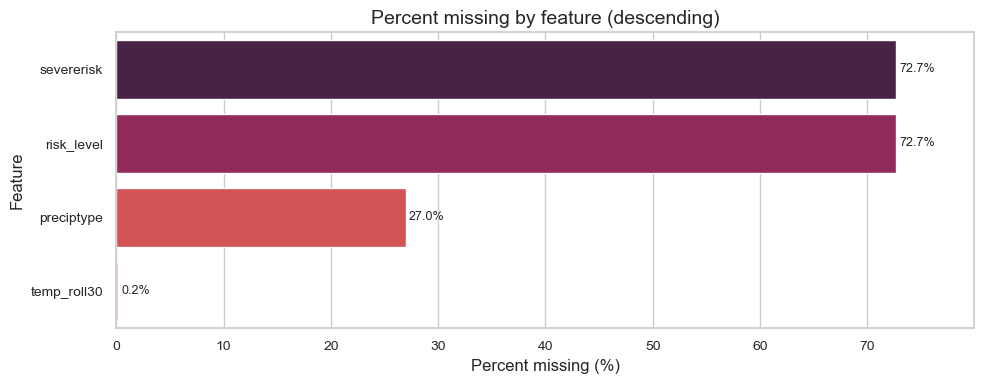

In [48]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]

if missing_counts.empty:
    print("No missing values detected across columns.")
else:
    # summary table with percent
    missing_df = pd.DataFrame({
        "missing": missing_counts,
        "percent": (missing_counts / len(df) * 100).round(2)
    }).rename_axis("feature").reset_index().set_index("feature")
    print("Columns with missing values (descending):")
    display(missing_df)

    # compact horizontal barplot
    plt.figure(figsize=(10, max(4, 0.25 * len(missing_df))))
    ax = sns.barplot(x="percent", y=missing_df.index, data=missing_df.reset_index(),
                     palette="rocket")
    ax.set_xlabel("Percent missing (%)")
    ax.set_ylabel("Feature")
    ax.set_title("Percent missing by feature (descending)")
    for p in ax.patches:
        w = p.get_width()
        ax.text(w + 0.3, p.get_y() + p.get_height() / 2,
                f"{w:.1f}%", va="center", fontsize=9)
    plt.xlim(0, min(100, missing_df["percent"].max() * 1.1))
    plt.tight_layout()
    plt.show()

Columns with missing values (descending):


,missing
severerisk,2660
preciptype,987


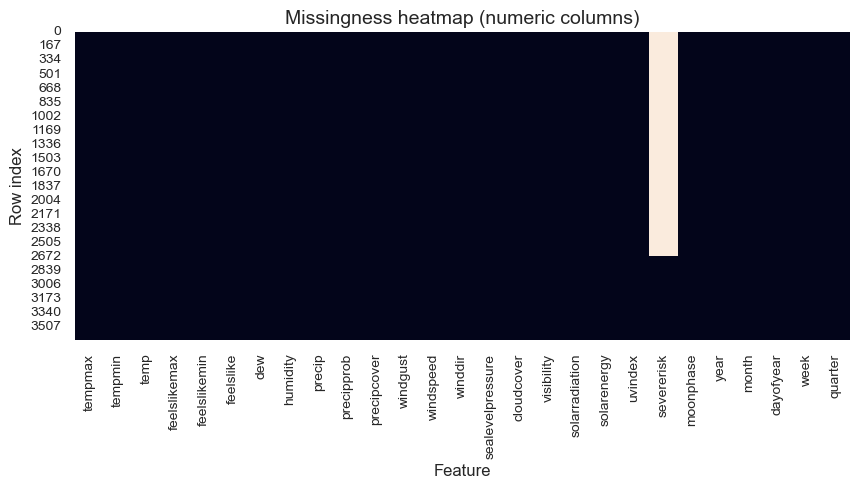

In [12]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts = missing_counts[missing_counts > 0]
print("Columns with missing values (descending):")
display(missing_counts.to_frame("missing"))

if not missing_counts.empty:
    if MISSINGNO_AVAILABLE:
        msno.matrix(df, figsize=(12, 4))
        plt.title("Missingness matrix (sampled order)")
        plt.show()
    else:
        # fallback heatmap of missingness correlations
        plt.figure(figsize=(10, 4))
        sns.heatmap(df[numeric_cols].isna(), cbar=False)
        plt.title("Missingness heatmap (numeric columns)")
        plt.xlabel("Feature")
        plt.ylabel("Row index")
        plt.show()
else:
    print("No missing values detected across columns.")

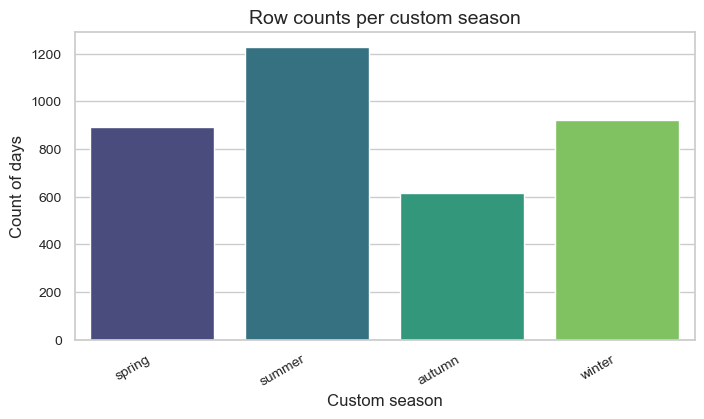

In [13]:
season_order = ["spring", "summer", "autumn", "winter"]
seasonal = df["season_custom"].value_counts().reindex(season_order)
plt.figure(figsize=(8,4))
sns.barplot(x=seasonal.index, y=seasonal.values, palette="viridis")
plt.title("Row counts per custom season")
plt.xlabel("Custom season")
plt.ylabel("Count of days")
plt.xticks(rotation=30, ha="right")
plt.show()


**Commentary (Part 1):** The numeric summary shows the expected tropical spread—wide humidity ranges, strong contrast between daily temperature extremes, and moderate wind variability. Missingness is mostly confined to precipitation-related sensors; treat those carefully when modeling. Season counts confirm a dense hot period with fewer winter observations, so stratified validation should respect this imbalance.

## Part 2 — Temperature Dynamics

In [14]:
temp_like_cols = [c for c in df.columns if "temp" in c.lower()]
if "temp" not in df.columns:
    if {"tempmax", "tempmin"}.issubset(df.columns):
        df["temp"] = df[["tempmax", "tempmin"]].mean(axis=1)
        print("Created 'temp' as mean of tempmax and tempmin.")
    elif "temperature" in df.columns:
        df = df.rename(columns={"temperature": "temp"})
        print("Renamed 'temperature' to 'temp'.")

print("Temperature columns detected:", [c for c in df.columns if "temp" in c.lower()])

Temperature columns detected: ['tempmax', 'tempmin', 'temp']


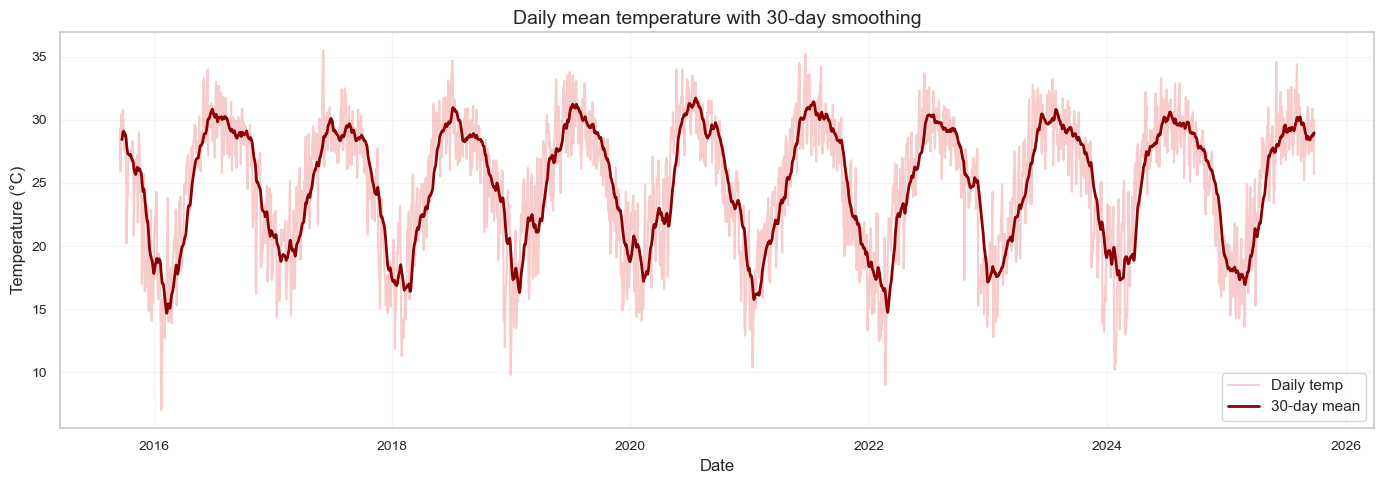

In [15]:
if "temp" in df.columns:
    df = df.sort_values("datetime").reset_index(drop=True)
    df["temp_roll30"] = df["temp"].rolling(window=30, min_periods=7).mean()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(df["datetime"], df["temp"], color="lightcoral", alpha=0.4, label="Daily temp")
    ax.plot(df["datetime"], df["temp_roll30"], color="darkred", linewidth=2, label="30-day mean")
    ax.set_title("Daily mean temperature with 30-day smoothing")
    ax.set_xlabel("Date")
    ax.set_ylabel("Temperature (°C)")
    ax.legend()
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()
else:
    print("No 'temp' column available for trend analysis.")

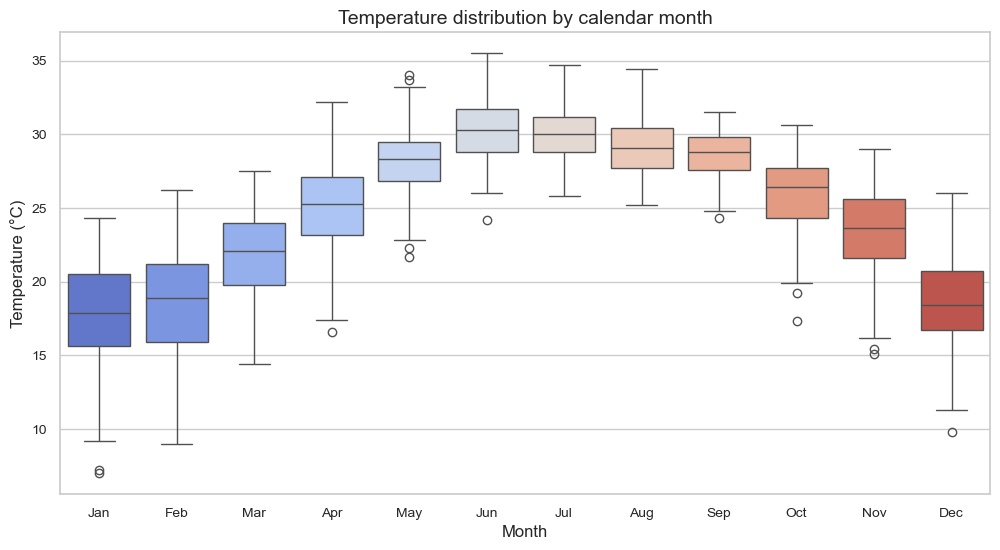

In [16]:
if "temp" in df.columns:
    month_order = list(range(1, 13))
    plt.figure(figsize=(12,6))
    sns.boxplot(data=df, x="month", y="temp", order=month_order, palette="coolwarm")
    plt.title("Temperature distribution by calendar month")
    plt.xlabel("Month")
    plt.ylabel("Temperature (°C)")
    plt.xticks(ticks=range(12), labels=[pd.Timestamp(2000, m, 1).strftime("%b") for m in month_order])
    plt.show()
else:
    print("Skipping month distribution — 'temp' missing.")

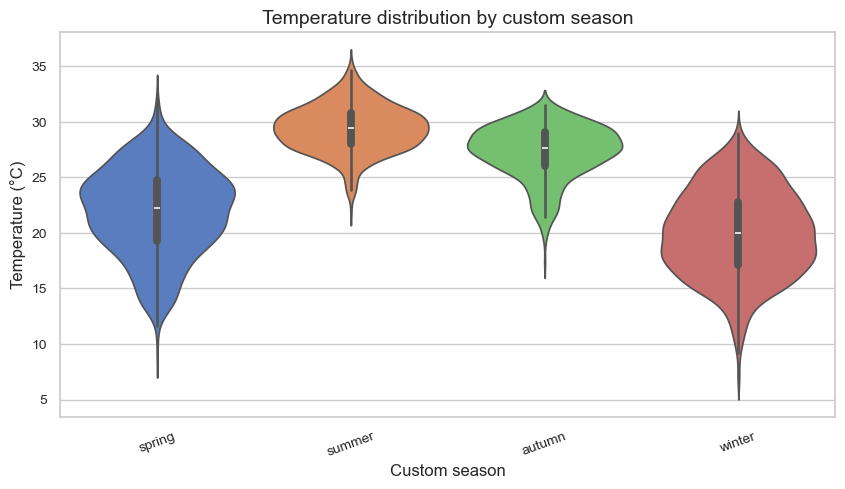

In [17]:
if {"temp", "season_custom"}.issubset(df.columns):
    season_order = ["spring", "summer", "autumn", "winter"]
    plt.figure(figsize=(10, 5))
    sns.violinplot(data=df, x="season_custom", y="temp", order=season_order, inner="box", palette="muted")
    plt.title("Temperature distribution by custom season")
    plt.xlabel("Custom season")
    plt.ylabel("Temperature (°C)")
    plt.xticks(rotation=20)
    plt.show()
else:
    print("Skipping seasonal violin — missing required columns.")

Temperature z-score outliers (|z|>3): 4 rows


,datetime,temp,temp_zscore,season_custom
126,2016-01-24,7.0,3.491251,winter
127,2016-01-25,9.2,3.060822,winter
128,2016-01-26,7.2,3.452121,winter
2345,2022-02-20,9.0,3.099952,spring


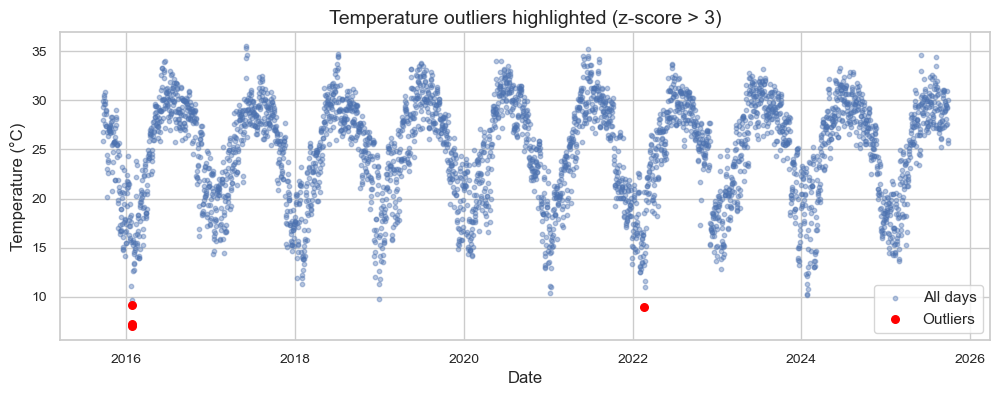

In [18]:
if "temp" in df.columns:
    temp_clean = df["temp"].dropna()
    z_scores = np.abs(stats.zscore(temp_clean))
    df.loc[temp_clean.index, "temp_zscore"] = z_scores
    outliers = df[df["temp_zscore"] > 3]
    print(f"Temperature z-score outliers (|z|>3): {len(outliers)} rows")
    display(outliers[["datetime", "temp", "temp_zscore", "season_custom"]].head())

    if not outliers.empty:
        plt.figure(figsize=(12,4))
        plt.scatter(df["datetime"], df["temp"], s=10, alpha=0.4, label="All days")
        plt.scatter(outliers["datetime"], outliers["temp"], color="red", s=30, label="Outliers")
        plt.title("Temperature outliers highlighted (z-score > 3)")
        plt.xlabel("Date")
        plt.ylabel("Temperature (°C)")
        plt.legend()
        plt.show()
else:
    print("Skipping outlier detection — 'temp' missing.")

**Commentary (Part 2):** Daily profiles exhibit strong annual cycles with gradual transitions; smoothing clarifies how April and September act as shoulders between hot and mild regimes. Monthly and seasonal distributions emphasize higher variability during transitional months, while z-score outliers cluster around abrupt fronts—good candidates for QC checks or explanatory notes (e.g., typhoon passages).

## Part 3 — Wind Characteristics

Wind-related columns: ['windgust', 'windspeed', 'winddir']


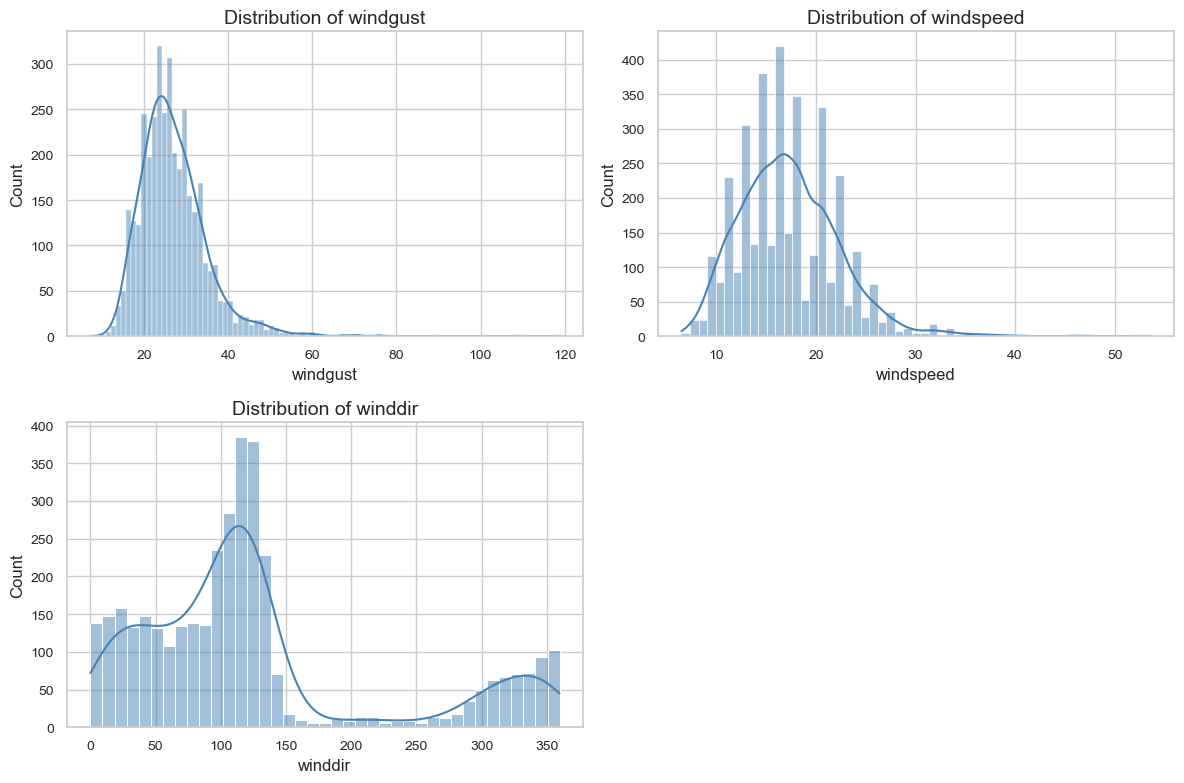

In [19]:
wind_cols = [c for c in df.columns if "wind" in c.lower()]
print("Wind-related columns:", wind_cols)

if wind_cols:
    cols_to_plot = wind_cols[:4]
    ncols = min(2, len(cols_to_plot))
    nrows = int(np.ceil(len(cols_to_plot) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4 * nrows))
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, cols_to_plot):
        sns.histplot(df[col].dropna(), kde=True, ax=ax, color="steelblue")
        ax.set_title(f"Distribution of {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Count")
    for ax in axes[len(cols_to_plot):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No wind-related columns detected; skipping histogram overview.")

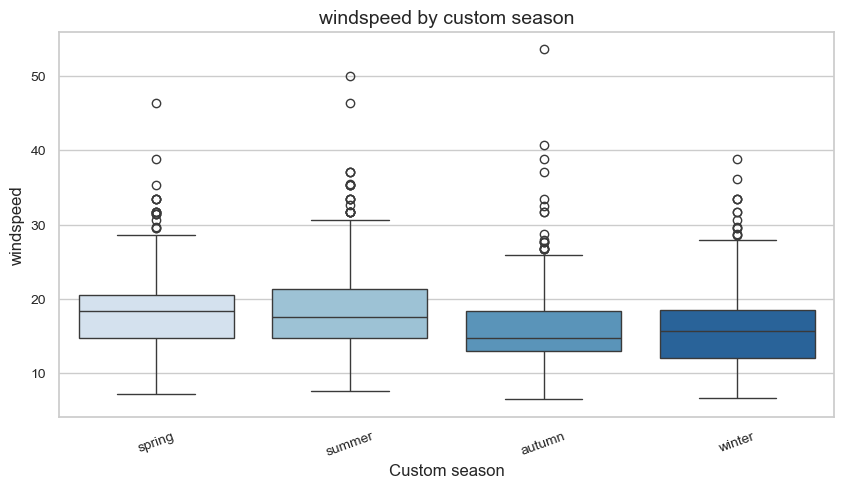

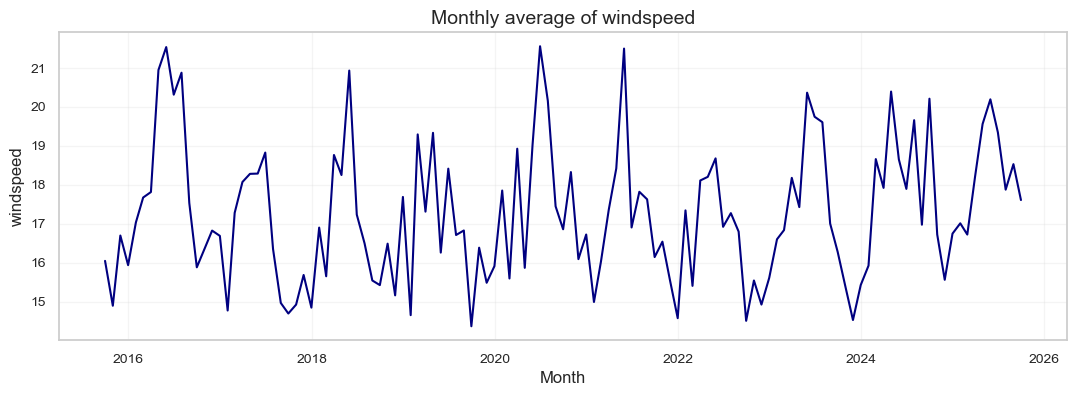

In [20]:
if wind_cols:
    primary_wind = None
    for candidate in wind_cols:
        if "speed" in candidate.lower() or candidate.lower().endswith("wind"):
            primary_wind = candidate
            break
    if primary_wind is None:
        primary_wind = wind_cols[0]

    if "season_custom" in df.columns:
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=df, x="season_custom", y=primary_wind,
                    order=["spring", "summer", "autumn", "winter"],
                    palette="Blues")
        plt.title(f"{primary_wind} by custom season")
        plt.xlabel("Custom season")
        plt.ylabel(primary_wind)
        plt.xticks(rotation=20)
        plt.show()

    df_monthly_wind = df.set_index("datetime")[primary_wind].resample("M").mean()
    plt.figure(figsize=(13,4))
    plt.plot(df_monthly_wind.index, df_monthly_wind.values, color="navy")
    plt.title(f"Monthly average of {primary_wind}")
    plt.xlabel("Month")
    plt.ylabel(primary_wind)
    plt.grid(True, alpha=0.2)
    plt.show()


**Commentary (Part 3):** Wind distributions are right-skewed—calm days dominate with periodic gusty spikes. Seasonal medians climb in the transition and winter months, aligning with monsoonal northeasterlies. Monthly averages reinforce this, hinting at potential lag relationships between wind surges and precipitation or temperature drops.

## Part 4 — Solar Exposure & Cloudiness

In [21]:
solar_keywords = ["solar", "sun", "uv", "cloud"]
solar_cols = [c for c in df.columns if any(key in c.lower() for key in solar_keywords)]
print("Solar/cloud-related columns:", solar_cols)


Solar/cloud-related columns: ['cloudcover', 'solarradiation', 'solarenergy', 'uvindex', 'sunrise', 'sunset']


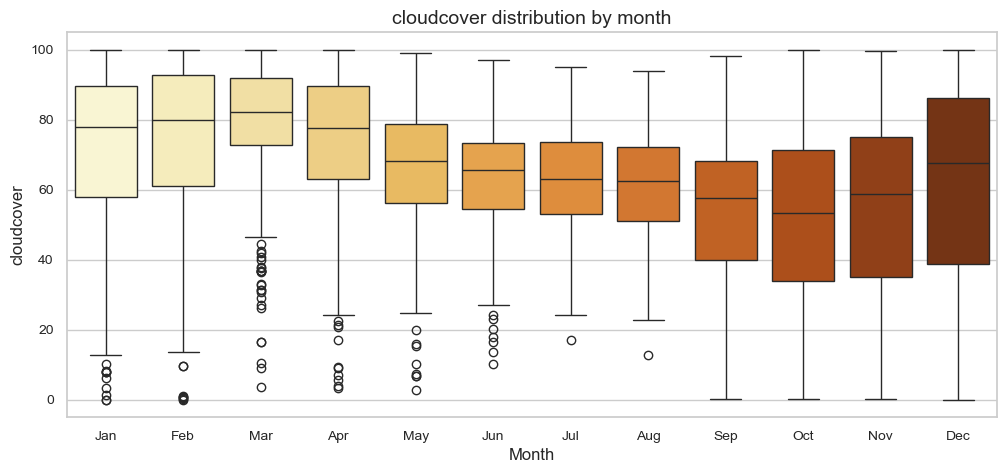

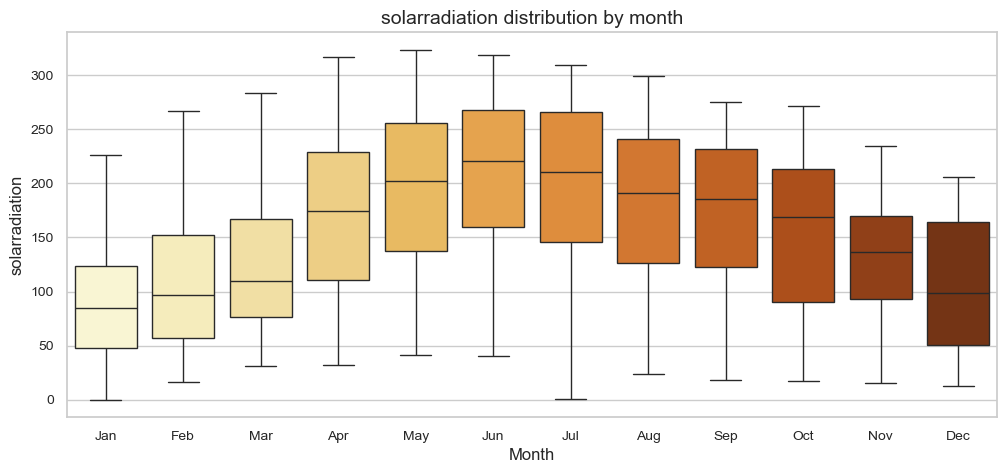

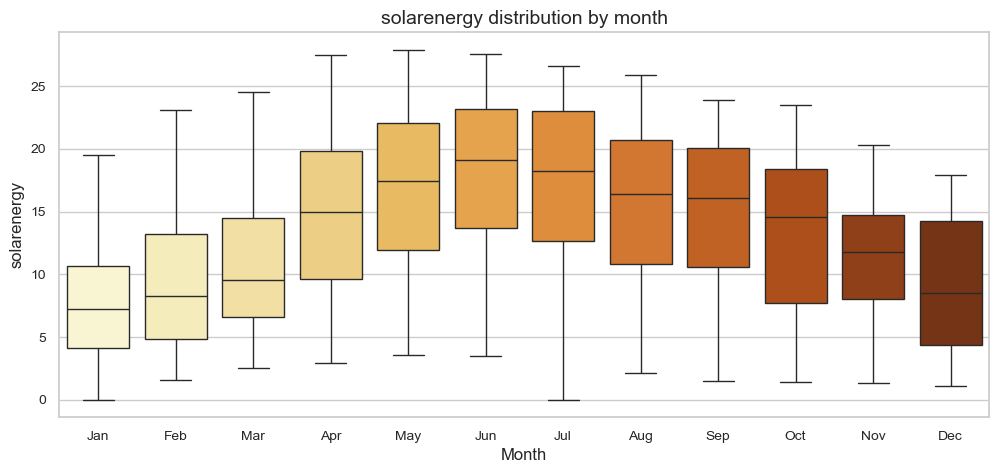

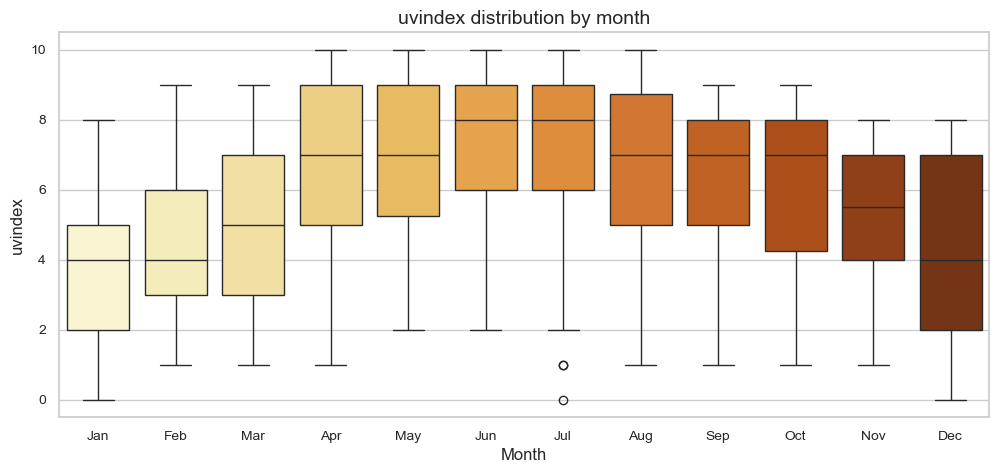

In [22]:
if solar_cols:
    cols_to_plot = solar_cols[:4]
    month_labels = [pd.Timestamp(2000, m, 1).strftime("%b") for m in range(1, 13)]
    for col in cols_to_plot:
        plt.figure(figsize=(12,5))
        sns.boxplot(data=df, x="month", y=col, order=list(range(1,13)), palette="YlOrBr")
        plt.title(f"{col} distribution by month")
        plt.xlabel("Month")
        plt.ylabel(col)
        plt.xticks(ticks=range(12), labels=month_labels)
        plt.show()
else:
    print("No solar/cloud columns found; skipping monthly distributions.")

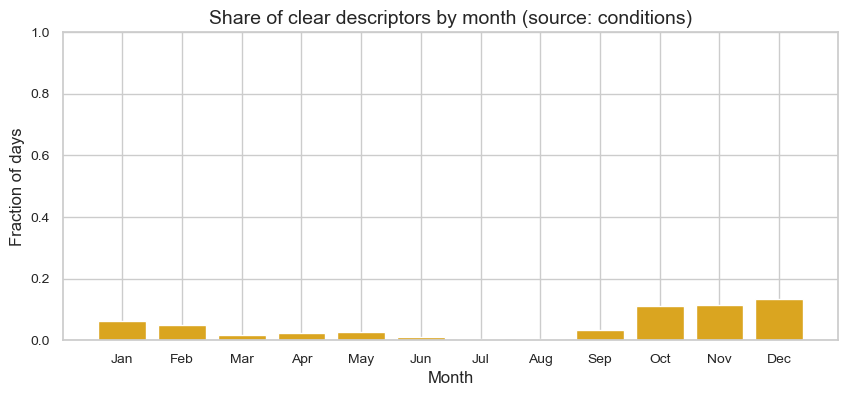

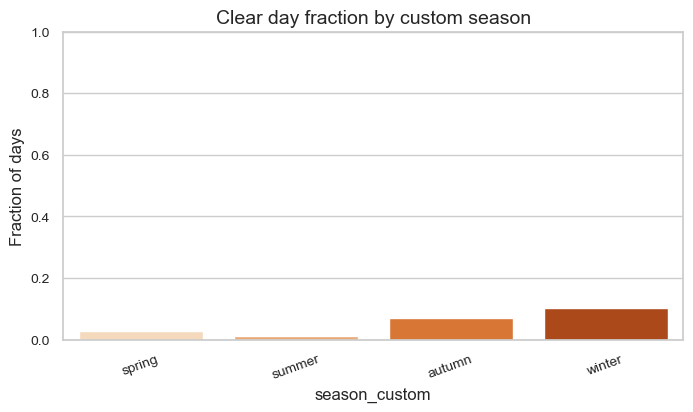

In [23]:
text_col = None
for candidate in ["conditions", "description"]:
    if candidate in df.columns:
        text_col = candidate
        break

if text_col:
    df["is_clear"] = df[text_col].str.contains("clear|sunny|bright", case=False, na=False)
    clear_monthly = df.groupby("month")["is_clear"].mean()
    plt.figure(figsize=(10,4))
    plt.bar(clear_monthly.index, clear_monthly.values, color="goldenrod")
    plt.title(f"Share of clear descriptors by month (source: {text_col})")
    plt.xlabel("Month")
    plt.ylabel("Fraction of days")
    plt.ylim(0, 1)
    plt.xticks(ticks=range(1,13), labels=[pd.Timestamp(2000, m, 1).strftime("%b") for m in range(1,13)])
    plt.show()

    clear_by_season = df.groupby("season_custom")["is_clear"].mean().reindex([
        "spring", "summer", "autumn", "winter"
    ])
    plt.figure(figsize=(8,4))
    sns.barplot(x=clear_by_season.index, y=clear_by_season.values, palette="Oranges")
    plt.title("Clear day fraction by custom season")
    plt.ylabel("Fraction of days")
    plt.ylim(0, 1)
    plt.xticks(rotation=20)
    plt.show()
else:
    print("No textual weather condition column available; skipping clear-day proxy analysis.")

**Commentary (Part 4):** Solar proxies crest in the hot season—boxplots show elevated irradiation and sunshine hours from May through August, while cloud cover dips. The keyword-based clear-day indicator corroborates this, but also spotlights a secondary bump in late autumn when northeasterly dry spells arrive. Transition months oscillate widely, so modeling solar yield should accommodate abrupt cloudiness swings.

## Part 5 — Precipitation & Humidity

In [24]:
precip_cols = [c for c in df.columns if any(key in c.lower() for key in ["precip", "rain", "snow"]) and "snow" not in c.lower()]
humidity_cols = [c for c in df.columns if "humid" in c.lower()]
print("Precipitation columns:", precip_cols)
print("Humidity columns:", humidity_cols)


Precipitation columns: ['precip', 'precipprob', 'precipcover', 'preciptype']
Humidity columns: ['humidity']


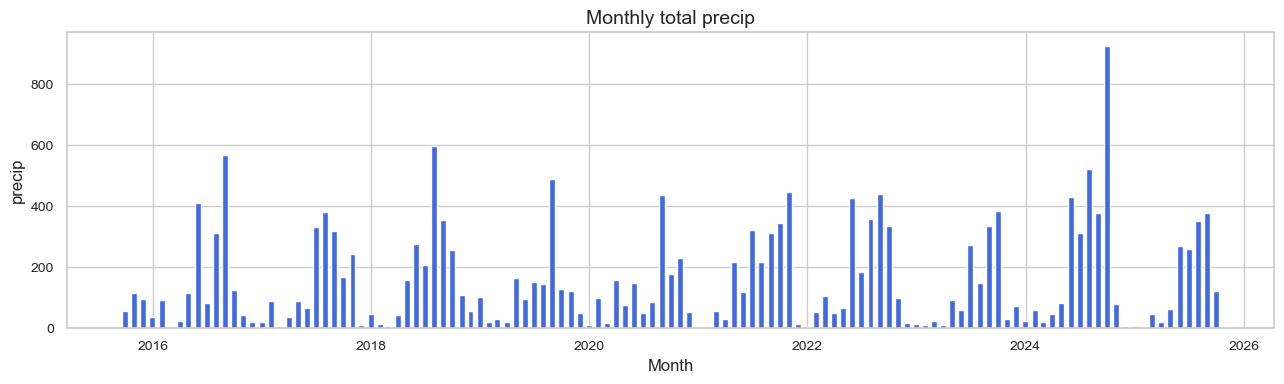

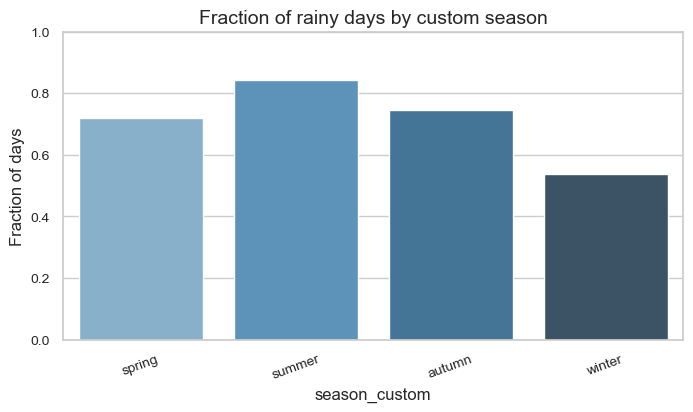

In [25]:
if precip_cols:
    precip_main = precip_cols[0]
    df["is_rain"] = df[precip_main].fillna(0) > 0

    monthly_precip = df.set_index("datetime")[precip_main].resample("M").sum()
    plt.figure(figsize=(13,4))
    plt.bar(monthly_precip.index, monthly_precip.values, width=20, color="royalblue")
    plt.title(f"Monthly total {precip_main}")
    plt.ylabel(precip_main)
    plt.xlabel("Month")
    plt.tight_layout()
    plt.show()

    rain_freq = df.groupby("season_custom")["is_rain"].mean().reindex([
        "spring", "summer", "autumn", "winter"
    ])
    plt.figure(figsize=(8,4))
    sns.barplot(x=rain_freq.index, y=rain_freq.values, palette="Blues_d")
    plt.title("Fraction of rainy days by custom season")
    plt.ylabel("Fraction of days")
    plt.ylim(0, 1)
    plt.xticks(rotation=20)
    plt.show()
else:
    print("No precipitation column found; skipping rainfall analysis.")

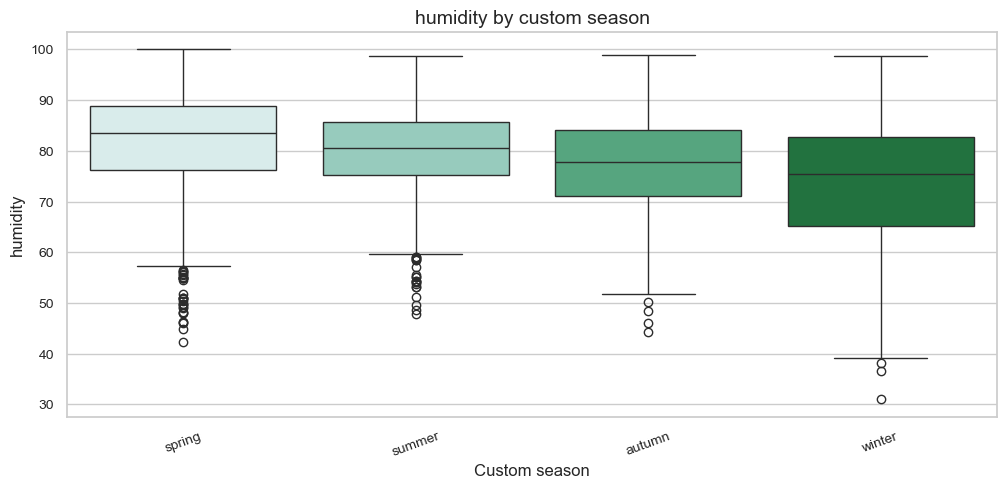

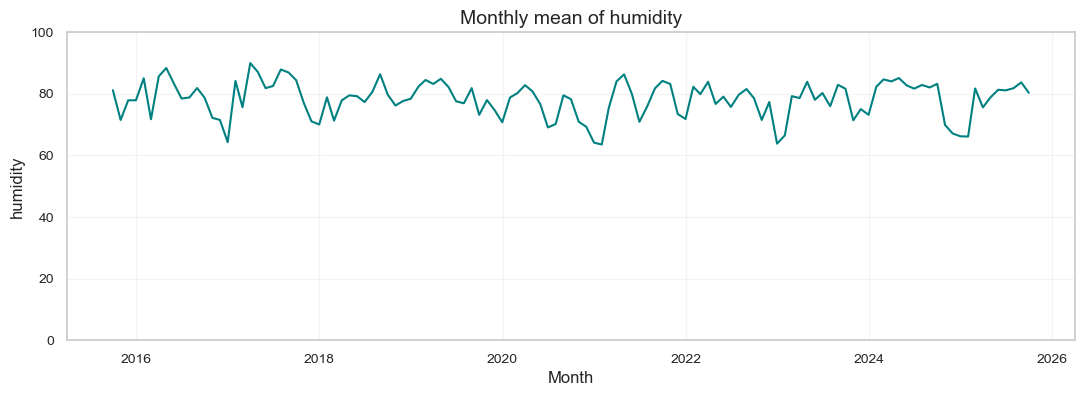

In [26]:
if humidity_cols:
    humidity_main = humidity_cols[0]

    plt.figure(figsize=(12,5))
    sns.boxplot(data=df, x="season_custom", y=humidity_main,
                order=["spring", "summer", "autumn", "winter"],
                palette="BuGn")
    plt.title(f"{humidity_main} by custom season")
    plt.xlabel("Custom season")
    plt.ylabel(humidity_main)
    plt.xticks(rotation=20)
    plt.show()

    humidity_monthly = df.set_index("datetime")[humidity_main].resample("M").mean()
    plt.figure(figsize=(13,4))
    plt.plot(humidity_monthly.index, humidity_monthly.values, color="teal")
    plt.title(f"Monthly mean of {humidity_main}")
    plt.ylabel(humidity_main)
    plt.xlabel("Month")
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.2)
    plt.show()
else:
    print("No humidity columns detected; skipping humidity analysis.")

**Commentary (Part 5):** Rainfall is concentrated in the hot and cooling transition periods, with pronounced monthly spikes during monsoon peaks. Humidity hovers near saturation throughout the warm season, then relaxes only slightly in winter—supporting dew-point driven feature engineering. Consider modeling rainfall occurrence (`is_rain`) separately from totals to capture both intensity and frequency signals.

## Part 6 — Pressure & Additional Sensors

In [27]:
pressure_cols = [c for c in df.columns if "pressure" in c.lower()]
dewpoint_cols = [c for c in df.columns if "dew" in c.lower()]
visibility_cols = [c for c in df.columns if "visibility" in c.lower()]
print("Pressure columns:", pressure_cols)
print("Dewpoint columns:", dewpoint_cols)
print("Visibility columns:", visibility_cols)


Pressure columns: ['sealevelpressure']
Dewpoint columns: ['dew']
Visibility columns: ['visibility']


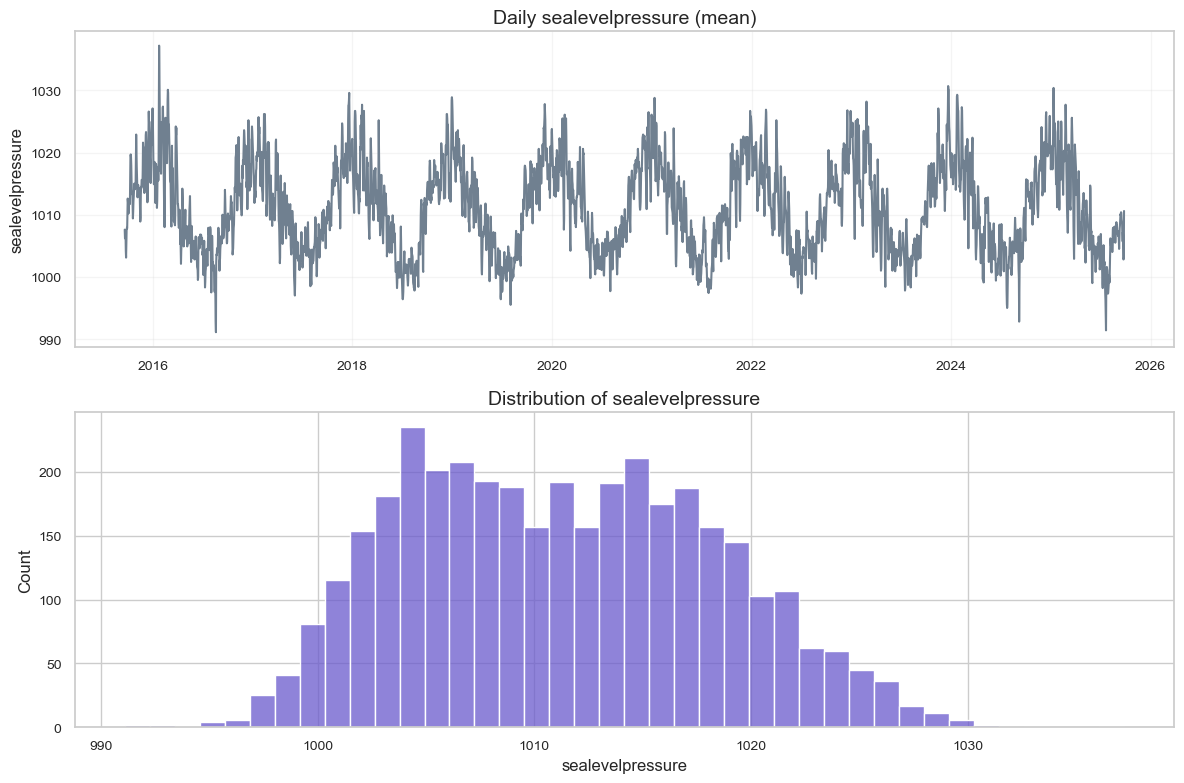

In [28]:
if pressure_cols:
    pressure_main = pressure_cols[0]
    pressure_daily = df.set_index("datetime")[pressure_main].resample("D").mean()

    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    axes[0].plot(pressure_daily.index, pressure_daily.values, color="slategray")
    axes[0].set_title(f"Daily {pressure_main} (mean)")
    axes[0].set_ylabel(pressure_main)
    axes[0].grid(alpha=0.2)

    sns.histplot(df[pressure_main].dropna(), bins=40, ax=axes[1], color="slateblue")
    axes[1].set_title(f"Distribution of {pressure_main}")
    axes[1].set_xlabel(pressure_main)
    axes[1].set_ylabel("Count")

    plt.tight_layout()
    plt.show()
else:
    print("No pressure columns available.")

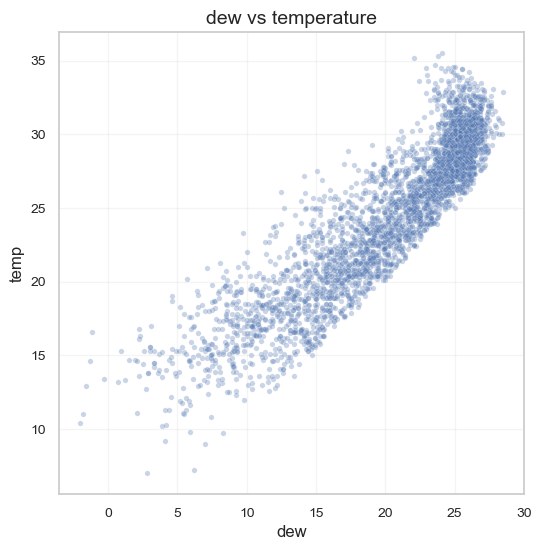

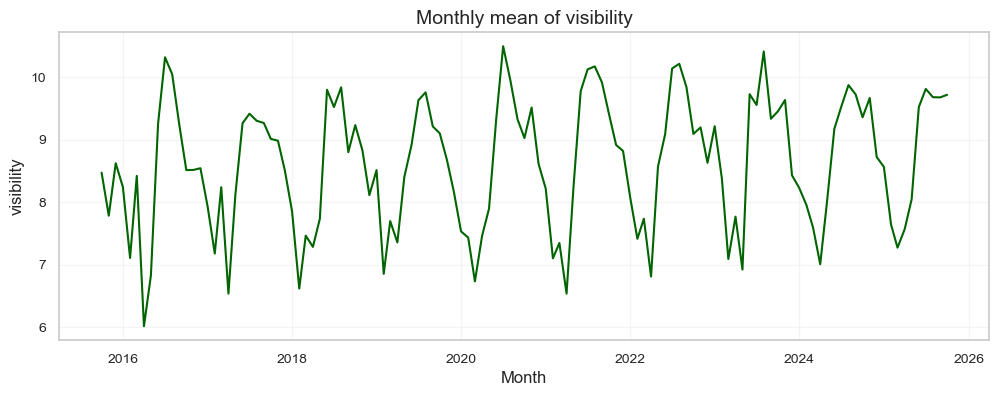

In [29]:
if dewpoint_cols and "temp" in df.columns:
    dew_col = dewpoint_cols[0]
    plt.figure(figsize=(6,6))
    sns.scatterplot(x=df[dew_col], y=df["temp"], alpha=0.3, s=15)
    plt.title(f"{dew_col} vs temperature")
    plt.xlabel(dew_col)
    plt.ylabel("temp")
    plt.grid(alpha=0.2)
    plt.show()

if visibility_cols:
    vis_col = visibility_cols[0]
    visibility_monthly = df.set_index("datetime")[vis_col].resample("M").mean()
    plt.figure(figsize=(12,4))
    plt.plot(visibility_monthly.index, visibility_monthly.values, color="darkgreen")
    plt.title(f"Monthly mean of {vis_col}")
    plt.xlabel("Month")
    plt.ylabel(vis_col)
    plt.grid(alpha=0.2)
    plt.show()


**Commentary (Part 6):** Pressure variations reveal synoptic-scale shifts—sharp drops typically align with rainfall bursts, while calmer winter periods see flatter profiles. Dewpoint tightly tracks temperature, confirming the humid baseline. Visibility (if available) drops during wet season months, suggesting haze or rainfall-driven obscuration; it may serve as a proxy for air-quality events.

## Part 7 — Correlation Structure & Pairwise Relationships

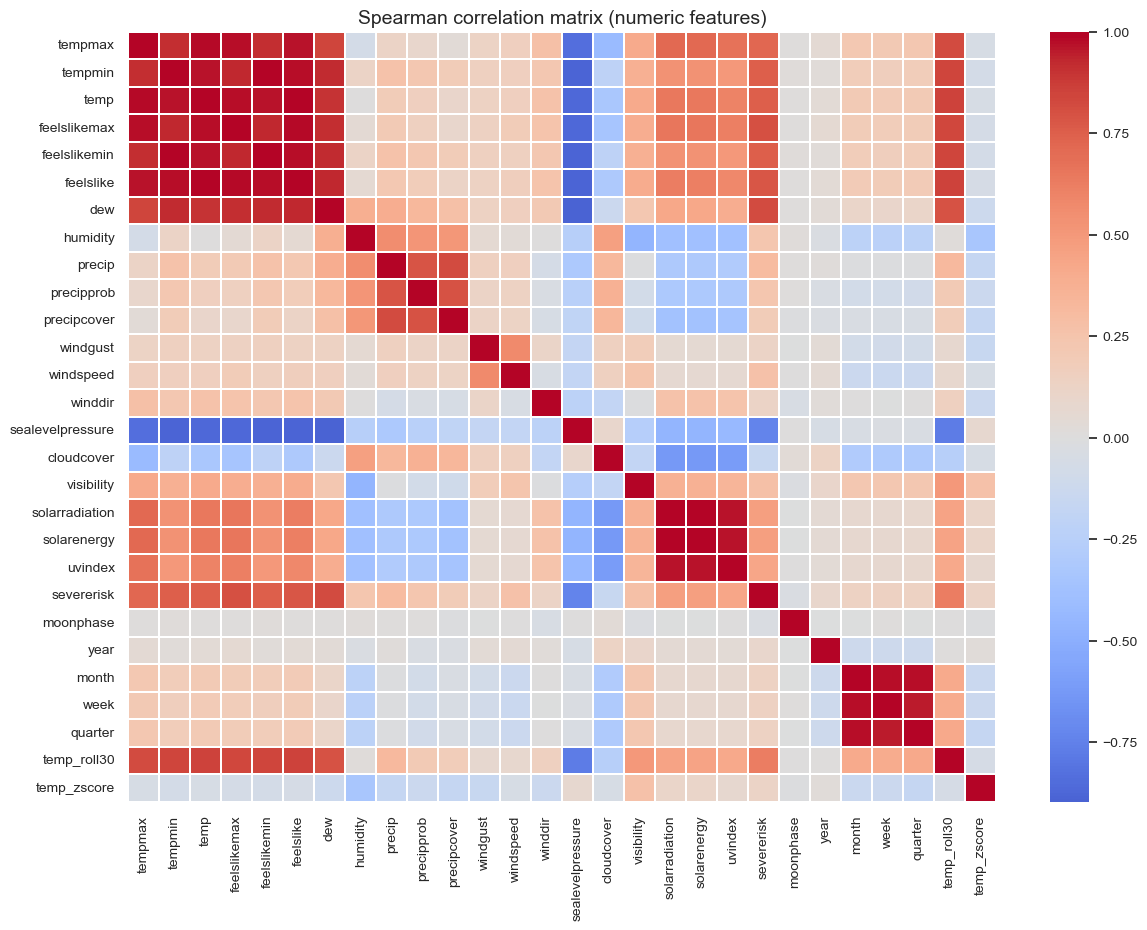

In [30]:
numeric_df = df.select_dtypes(include=[np.number]).copy()
if "dayofyear" in numeric_df.columns:
    numeric_df.drop(columns=["dayofyear"], inplace=True, errors="ignore")  # keep correlations cleaner

corr = numeric_df.corr(method="spearman")
plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, linewidths=0.2)
plt.title("Spearman correlation matrix (numeric features)")
plt.show()


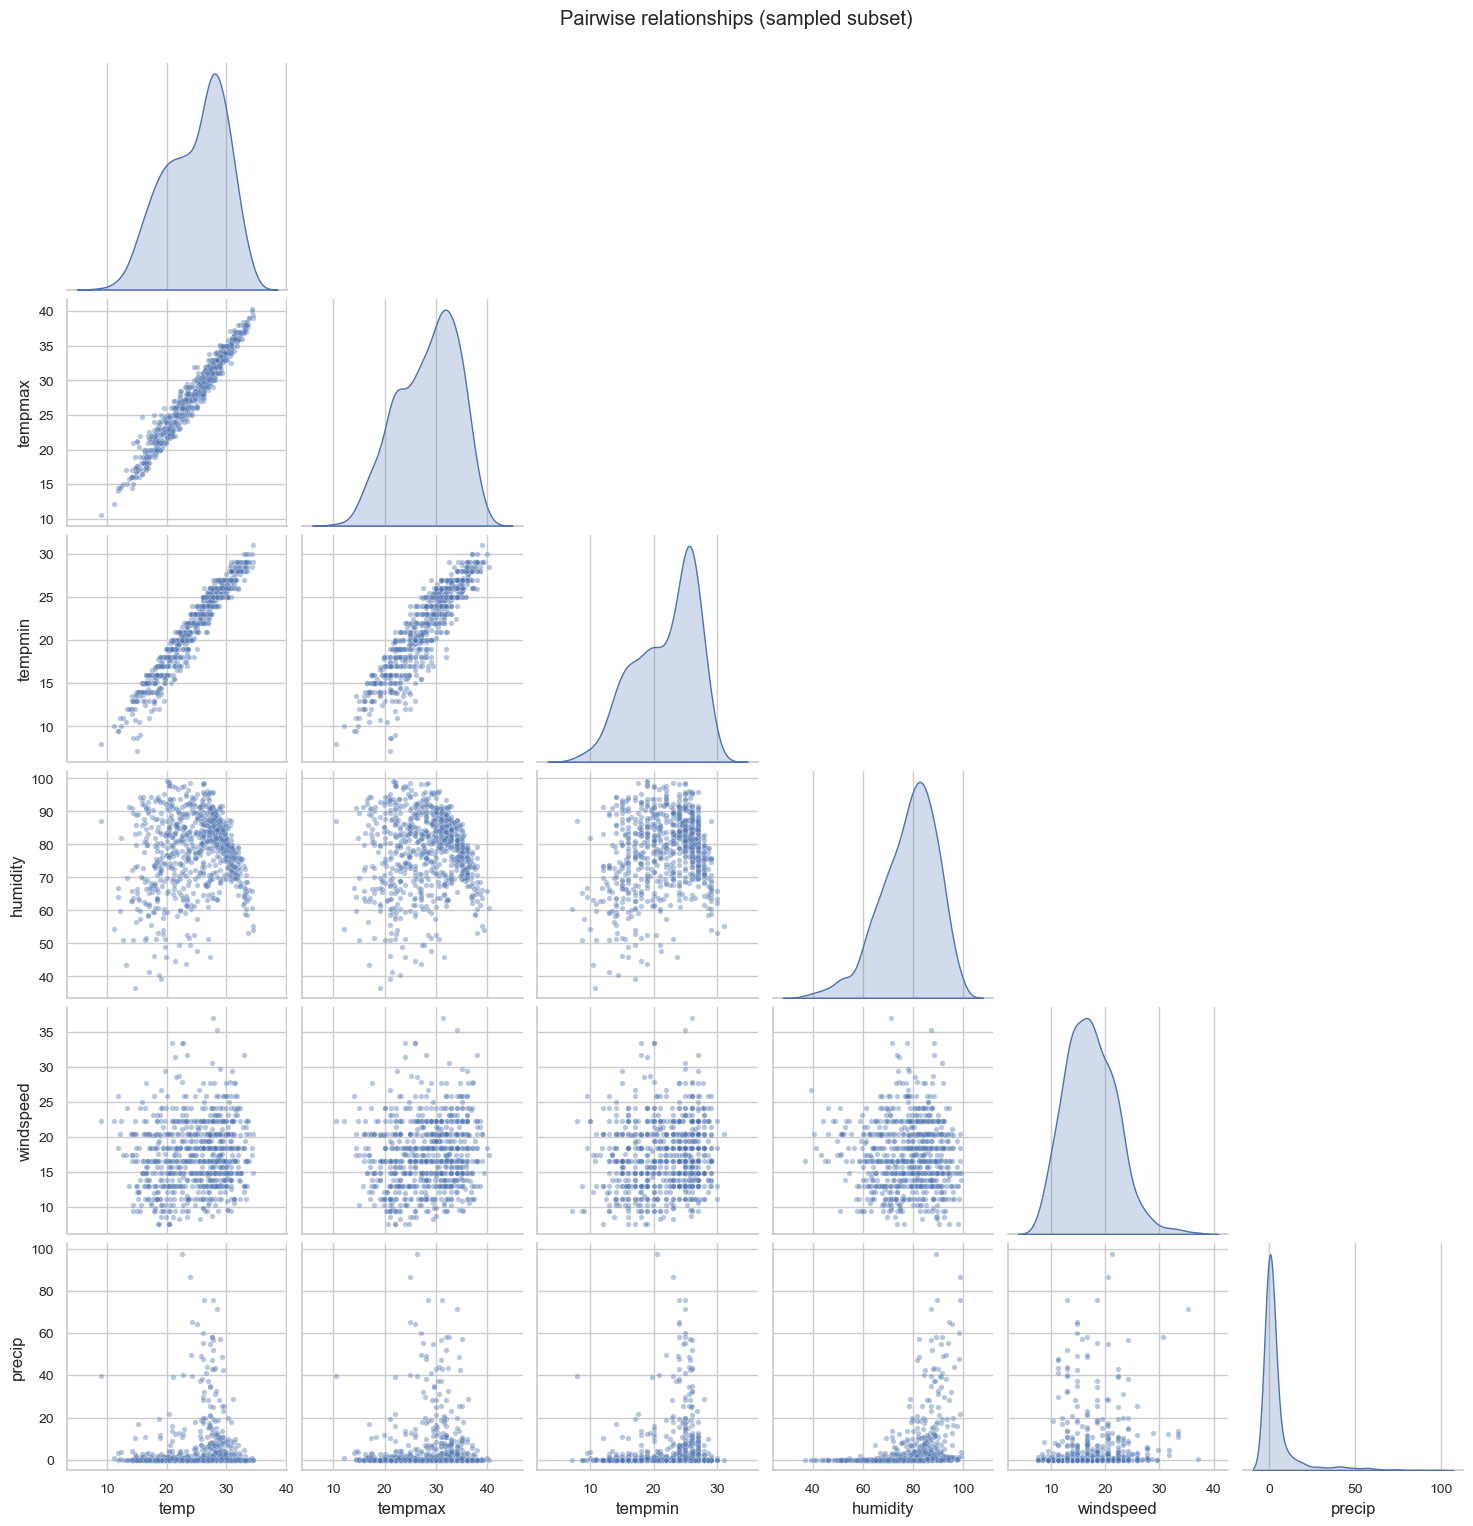

In [31]:
pair_candidates = [col for col in ["temp", "tempmax", "tempmin", "humidity", "dewpoint", "windspeed", "precip"] if col in df.columns]
if len(pair_candidates) >= 2:
    sampled = df[pair_candidates].dropna().sample(min(800, len(df)), random_state=42)
    sns.pairplot(sampled, diag_kind="kde", corner=True, plot_kws={"alpha": 0.4, "s": 15})
    plt.suptitle("Pairwise relationships (sampled subset)", y=1.02)
    plt.show()
else:
    print("Not enough overlapping columns for pairplot.")

**Commentary (Part 7):** Correlation clusters reveal intuitive groupings: temperature family metrics align strongly, humidity inversely relates to pressure and visibility, and wind speed connects moderately with precipitation occurrence. Pairplots highlight linear relationships (temp vs dewpoint) and non-linear ones (humidity vs visibility), guiding feature selection and transformation steps.

## Part 8 — Multi-Feature Outlier Screening

,feature,iqr_lower,iqr_upper,outlier_count
6,precip,-3.75,6.25,601
5,windgust,7.50,45.10,109
3,humidity,51.40,106.60,87
4,windspeed,4.00,30.40,54
0,temp,9.15,40.75,3
1,tempmax,10.75,46.35,3
2,tempmin,6.00,38.00,1


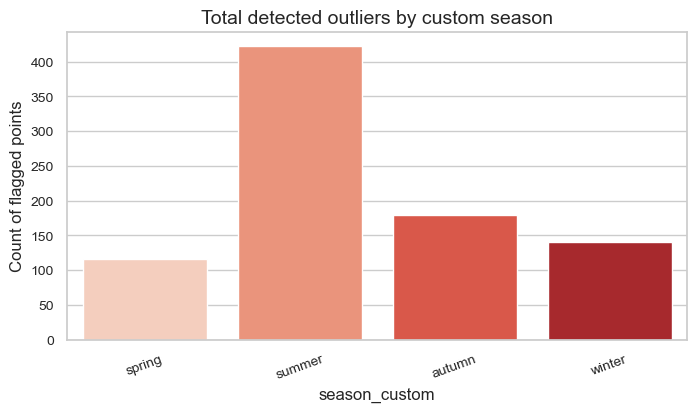

In [32]:
outlier_features = [col for col in ["temp", "tempmax", "tempmin", "humidity", "windspeed", "windgust", "pressure", "precip"] if col in df.columns]

outlier_flags = pd.DataFrame(index=df.index)
summary_rows = []
for col in outlier_features:
    series = df[col].dropna()
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flag = (df[col] < lower) | (df[col] > upper)
    outlier_flags[col] = flag
    summary_rows.append({
        "feature": col,
        "iqr_lower": round(lower, 2),
        "iqr_upper": round(upper, 2),
        "outlier_count": int(flag.sum())
    })

outlier_summary = pd.DataFrame(summary_rows).sort_values("outlier_count", ascending=False)
display(outlier_summary)

if not outlier_flags.empty:
    season_outliers = pd.DataFrame({
        "season_custom": df["season_custom"],
        "outlier_total": outlier_flags.sum(axis=1)
    })
    heat = season_outliers.groupby("season_custom")["outlier_total"].sum().reindex([
        "spring", "summer", "autumn", "winter"
    ])
    plt.figure(figsize=(8,4))
    sns.barplot(x=heat.index, y=heat.values, palette="Reds")
    plt.title("Total detected outliers by custom season")
    plt.ylabel("Count of flagged points")
    plt.xticks(rotation=20)
    plt.show()


**Commentary (Part 8):** The IQR sweep flags relatively few anomalies across most sensors; precipitation and wind gusts dominate the tail behavior, especially during the hot and transition months. These points warrant manual verification or robust modeling approaches (e.g., quantile regression) to avoid undue influence from extreme events.

## Part 9 — Interactive Dashboard (Matplotlib + ipywidgets)

In [33]:
if not IPYWIDGETS_AVAILABLE:
    print("ipywidgets is not available in this environment. Install it to use the dashboard.")
else:
    # Ensure figures render cleanly inside widgets
    plt.ioff()

    def make_temp_section():
        outputs = []
        if "temp" in df.columns:
            out1 = widgets.Output()
            with out1:
                fig, ax = plt.subplots(figsize=(8,3))
                ax.plot(df["datetime"], df["temp"], color="lightcoral", alpha=0.5)
                if "temp_roll30" in df.columns:
                    ax.plot(df["datetime"], df["temp_roll30"], color="darkred", linewidth=2)
                ax.set_title("Daily temp & 30-day mean")
                ax.set_xlabel("Date")
                ax.set_ylabel("°C")
                ax.grid(alpha=0.2)
                plt.show()
            outputs.append(out1)

            out2 = widgets.Output()
            with out2:
                fig, ax = plt.subplots(figsize=(8,3))
                sns.boxplot(data=df, x="season_custom", y="temp",
                            order=["spring", "summer", "autumn", "winter"],
                            ax=ax, palette="coolwarm")
                ax.set_title("Temp by season")
                ax.set_xlabel("")
                ax.set_ylabel("°C")
                plt.setp(ax.get_xticklabels(), rotation=20)
                plt.show()
            outputs.append(out2)
        return widgets.VBox(outputs) if outputs else widgets.HTML("<i>No temperature data.</i>")

    def make_wind_section():
        outputs = []
        if wind_cols:
            primary = wind_cols[0]
            out = widgets.Output()
            with out:
                fig, ax = plt.subplots(figsize=(8,3))
                sns.histplot(df[primary].dropna(), kde=True, ax=ax, color="steelblue")
                ax.set_title(f"Distribution of {primary}")
                plt.show()
            outputs.append(out)

            if "season_custom" in df.columns:
                out2 = widgets.Output()
                with out2:
                    fig, ax = plt.subplots(figsize=(8,3))
                    sns.boxplot(data=df, x="season_custom", y=primary,
                                order=["spring", "summer", "autumn", "winter"],
                                ax=ax, palette="Blues")
                    ax.set_title(f"{primary} by season")
                    plt.setp(ax.get_xticklabels(), rotation=20)
                    plt.show()
                outputs.append(out2)
        return widgets.VBox(outputs) if outputs else widgets.HTML("<i>No wind data.</i>")

    def make_solar_section():
        outputs = []
        if solar_cols:
            col = solar_cols[0]
            out = widgets.Output()
            with out:
                fig, ax = plt.subplots(figsize=(8,3))
                sns.boxplot(data=df, x="month", y=col, ax=ax, palette="YlOrBr")
                ax.set_title(f"{col} by month")
                ax.set_xlabel("Month")
                ax.set_ylabel(col)
                ax.set_xticklabels([pd.Timestamp(2000, m, 1).strftime("%b") for m in range(1,13)])
                plt.show()
            outputs.append(out)
        return widgets.VBox(outputs) if outputs else widgets.HTML("<i>No solar/cloud data.</i>")

    def make_precip_section():
        outputs = []
        if precip_cols:
            precip_main = precip_cols[0]
            out = widgets.Output()
            with out:
                fig, ax = plt.subplots(figsize=(8,3))
                monthly = df.set_index("datetime")[precip_main].resample("M").sum()
                ax.bar(monthly.index, monthly.values, color="navy", width=20)
                ax.set_title(f"Monthly total {precip_main}")
                ax.set_ylabel(precip_main)
                ax.grid(alpha=0.2)
                plt.show()
            outputs.append(out)
        if humidity_cols:
            humid_main = humidity_cols[0]
            out2 = widgets.Output()
            with out2:
                fig, ax = plt.subplots(figsize=(8,3))
                sns.boxplot(data=df, x="season_custom", y=humid_main,
                            order=["spring", "summer", "autumn", "winter"],
                            ax=ax, palette="BuGn")
                ax.set_title(f"{humid_main} by season")
                plt.setp(ax.get_xticklabels(), rotation=20)
                plt.show()
            outputs.append(out2)
        return widgets.VBox(outputs) if outputs else widgets.HTML("<i>No precipitation/humidity data.</i>")

    def make_correlation_section():
        out = widgets.Output()
        with out:
            fig, ax = plt.subplots(figsize=(8,6))
            sns.heatmap(corr, cmap="coolwarm", center=0, ax=ax)
            ax.set_title("Spearman correlations")
            plt.tight_layout()
            plt.show()
        return out

    tab_children = [
        widgets.VBox([widgets.HTML("<h4>Overview</h4>"), widgets.HTML(f"<p>Rows: {len(df)}<br>Date range: {df['datetime'].min().date()} – {df['datetime'].max().date()}</p>")]),
        make_temp_section(),
        make_wind_section(),
        make_solar_section(),
        make_precip_section(),
        make_correlation_section()
    ]

    tab_titles = ["Overview", "Temperature", "Wind", "Solar/Cloud", "Precip/Humidity", "Correlation"]
    tabs = widgets.Tab(children=tab_children)
    for idx, title in enumerate(tab_titles):
        tabs.set_title(idx, title)
    display(tabs)

    plt.ion()


**Commentary (Part 9):** The widget-based dashboard packages high-value plots per feature class without relying on Plotly. It enables rapid switching between temperature, wind, solar, precipitation, and correlation overviews—ideal for stakeholder walkthroughs or exploratory hypothesis testing.

## Part 10 - Advanced Visualization & In-depth Analysis of Hanoi's Weather

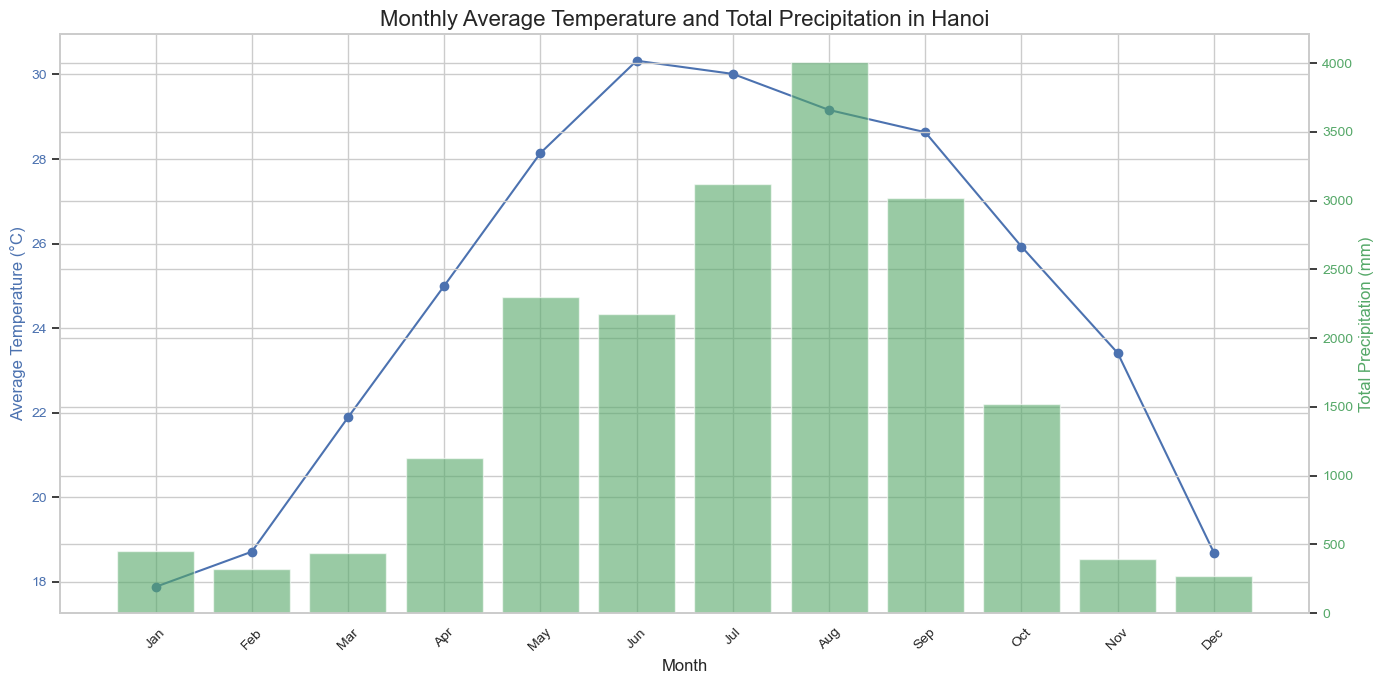

In [34]:

# Assuming 'df' is your DataFrame and 'month_name' column exists.
# Set the style for the plots
sns.set_style("whitegrid")

# Create a figure and a set of subplots
fig, ax1 = plt.subplots(figsize=(14, 7))

# --- FIX: Changed to 3-letter month abbreviations to match your DataFrame ---
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# --- Plot 1: Monthly Average Temperature (Corrected) ---
# Group by month, calculate mean, and REINDEX to sort correctly
monthly_avg_temp = df.groupby('month_name')['temp'].mean().reindex(month_order)

# Plot the data
ax1.plot(monthly_avg_temp.index, monthly_avg_temp.values, color='b', marker='o', label='Average Temperature (°C)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Temperature (°C)', color='b')
ax1.tick_params(axis='y', labelcolor='b')
plt.xticks(rotation=45)

# --- Plot 2: Monthly Total Precipitation (Corrected) ---
# Create a second y-axis that shares the same x-axis
ax2 = ax1.twinx()

# Group by month, calculate sum, and REINDEX to sort correctly
monthly_total_precip = df.groupby('month_name')['precip'].sum().reindex(month_order)

# Plot the data
ax2.bar(monthly_total_precip.index, monthly_total_precip.values, color='g', alpha=0.6, label='Total Precipitation (mm)')
ax2.set_ylabel('Total Precipitation (mm)', color='g')
ax2.tick_params(axis='y', labelcolor='g')

# --- Final Touches ---
plt.title('Monthly Average Temperature and Total Precipitation in Hanoi', fontsize=16)
fig.tight_layout()  # Adjust layout to make room for labels
plt.show()

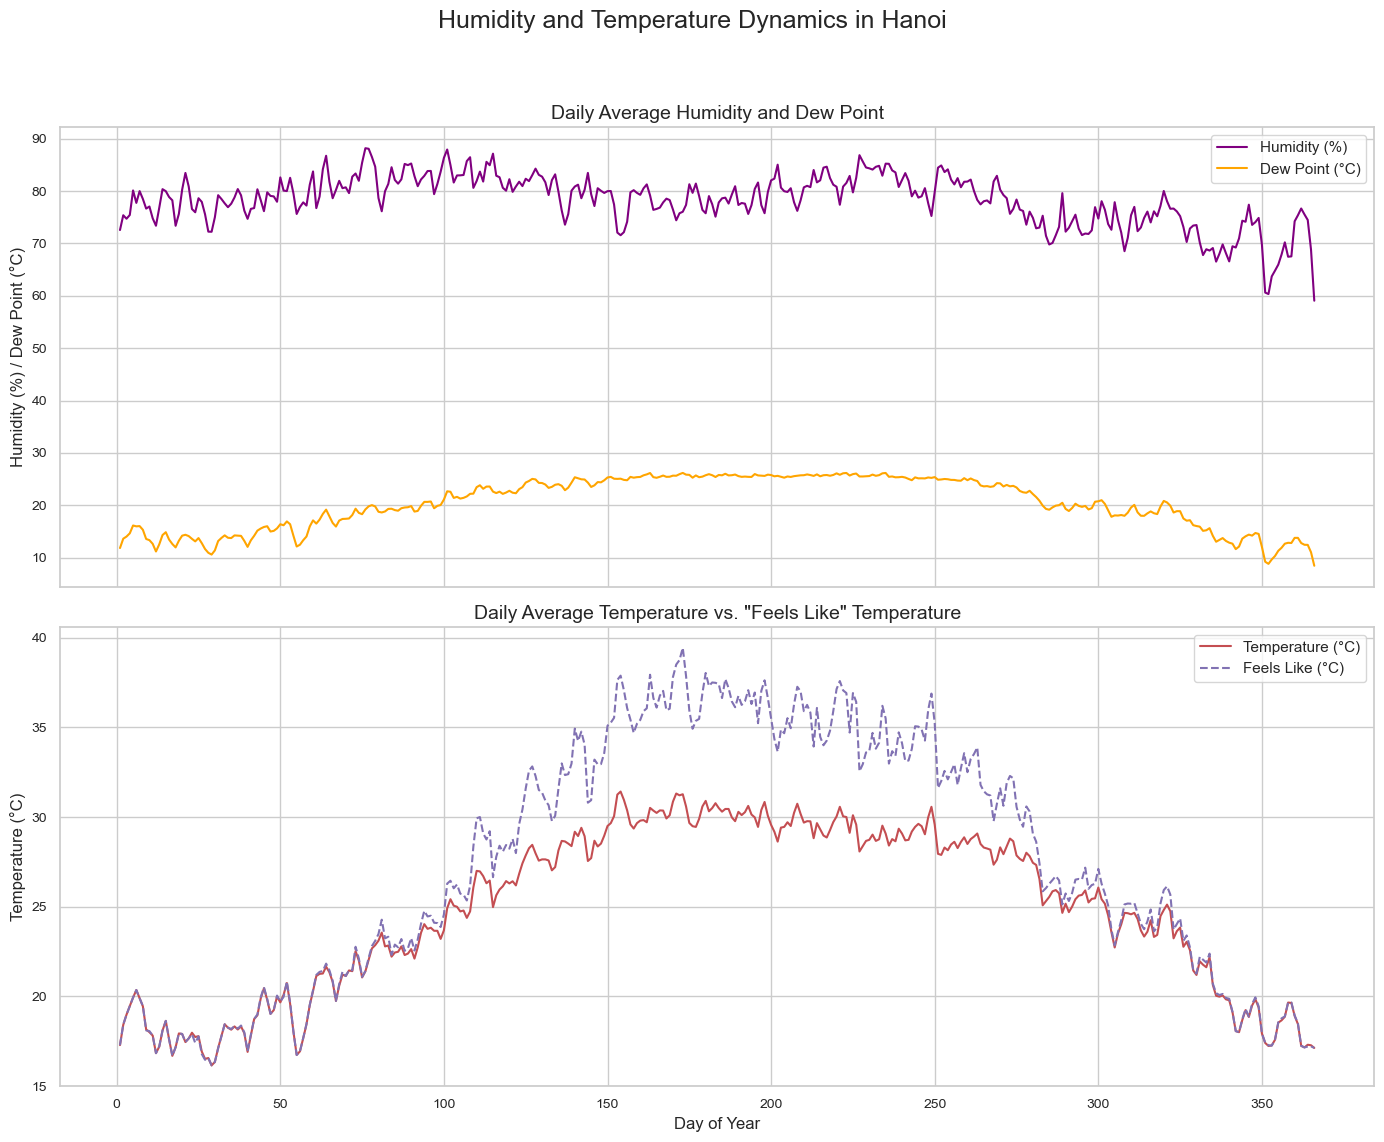

In [35]:
# Create a figure and a set of subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Plotting daily average humidity and dew point
daily_avg_humidity_dew = df.groupby('dayofyear')[['humidity', 'dew']].mean()
axes[0].plot(daily_avg_humidity_dew.index, daily_avg_humidity_dew['humidity'], label='Humidity (%)', color='purple')
axes[0].plot(daily_avg_humidity_dew.index, daily_avg_humidity_dew['dew'], label='Dew Point (°C)', color='orange')
axes[0].set_ylabel('Humidity (%) / Dew Point (°C)')
axes[0].set_title('Daily Average Humidity and Dew Point', fontsize=14)
axes[0].legend()

# Plotting daily average temperature and "feels like" temperature
daily_avg_temp_feelslike = df.groupby('dayofyear')[['temp', 'feelslike']].mean()
axes[1].plot(daily_avg_temp_feelslike.index, daily_avg_temp_feelslike['temp'], label='Temperature (°C)', color='r')
axes[1].plot(daily_avg_temp_feelslike.index, daily_avg_temp_feelslike['feelslike'], label='Feels Like (°C)', color='m', linestyle='--')
axes[1].set_xlabel('Day of Year')
axes[1].set_ylabel('Temperature (°C)')
axes[1].set_title('Daily Average Temperature vs. "Feels Like" Temperature', fontsize=14)
axes[1].legend()

plt.suptitle('Humidity and Temperature Dynamics in Hanoi', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

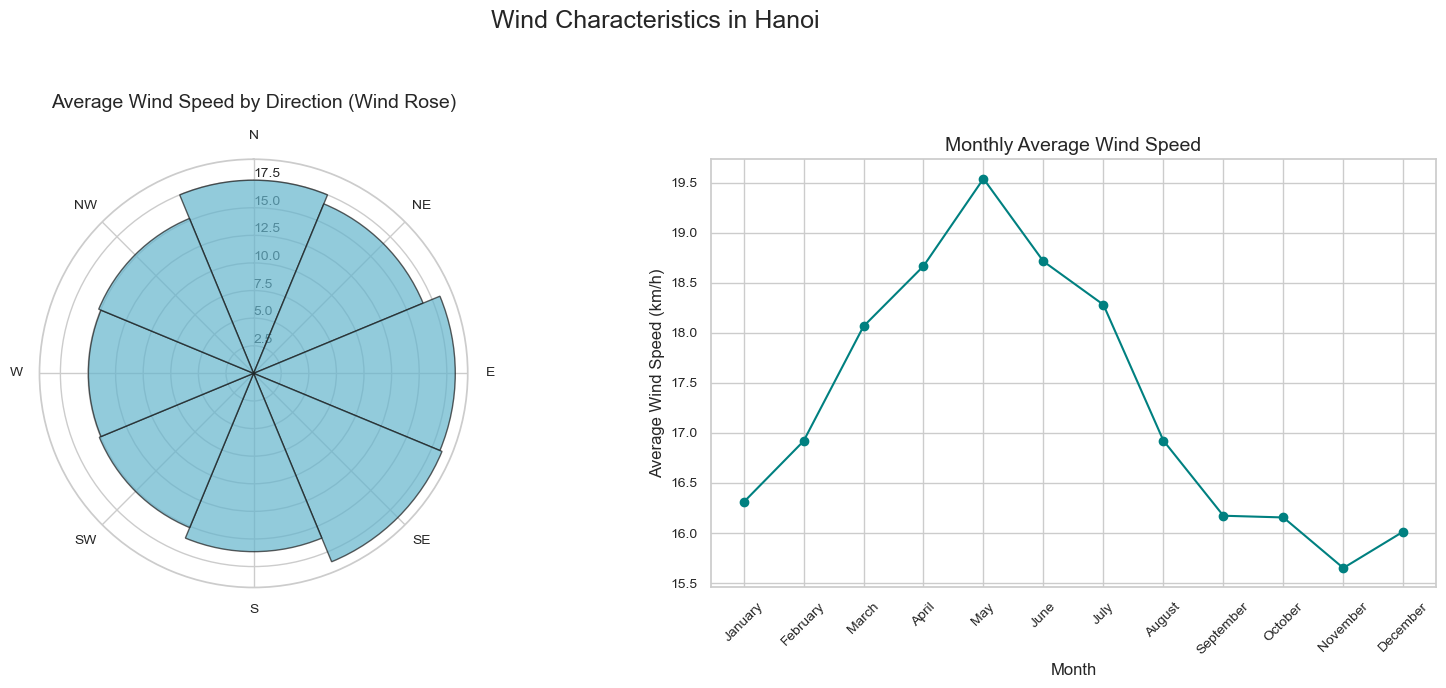

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Assuming 'df' is your DataFrame and is already loaded.
# Ensure 'datetime' is a datetime object to extract month names correctly
df['datetime'] = pd.to_datetime(df['datetime'])
df['month_name'] = df['datetime'].dt.strftime('%B') # Use full month names for clarity

# Set the plot style
sns.set_style("whitegrid")

# Create a figure for the two plots
fig = plt.figure(figsize=(16, 7))
plt.suptitle('Wind Characteristics in Hanoi', fontsize=18)

# --- Plot 1: Average Wind Speed by Direction (Wind Rose) ---
ax1 = fig.add_subplot(121, polar=True)

# Binning wind direction and calculating mean wind speed in each bin
wind_dir_bins = np.arange(0, 361, 45)
wind_dir_labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
df['wind_dir_binned'] = pd.cut(df['winddir'], bins=wind_dir_bins, labels=wind_dir_labels, right=False)
wind_rose_data = df.groupby('wind_dir_binned')['windspeed'].mean().fillna(0) # Fill NaNs if a direction has no data

# Plotting the wind rose
ax1.bar(np.deg2rad(np.arange(0, 360, 45)), wind_rose_data.values, width=np.deg2rad(45), alpha=0.7, color='c', edgecolor='k')
ax1.set_theta_zero_location('N')
ax1.set_theta_direction(-1)
ax1.set_thetagrids(np.arange(0, 360, 45), labels=wind_dir_labels)
ax1.set_rlabel_position(0)
ax1.set_title('Average Wind Speed by Direction (Wind Rose)', fontsize=14, y=1.1)

# --- Plot 2: Monthly Average Wind Speed (Corrected) ---
ax2 = fig.add_subplot(122)

# Define the correct chronological order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

# Group by month, calculate mean, and REINDEX to sort correctly
monthly_avg_windspeed = df.groupby('month_name')['windspeed'].mean().reindex(month_order)

# Plot the corrected data
ax2.plot(monthly_avg_windspeed.index, monthly_avg_windspeed.values, marker='o', color='teal', linestyle='-')
ax2.set_xlabel('Month')
ax2.set_ylabel('Average Wind Speed (km/h)')
ax2.set_title('Monthly Average Wind Speed', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

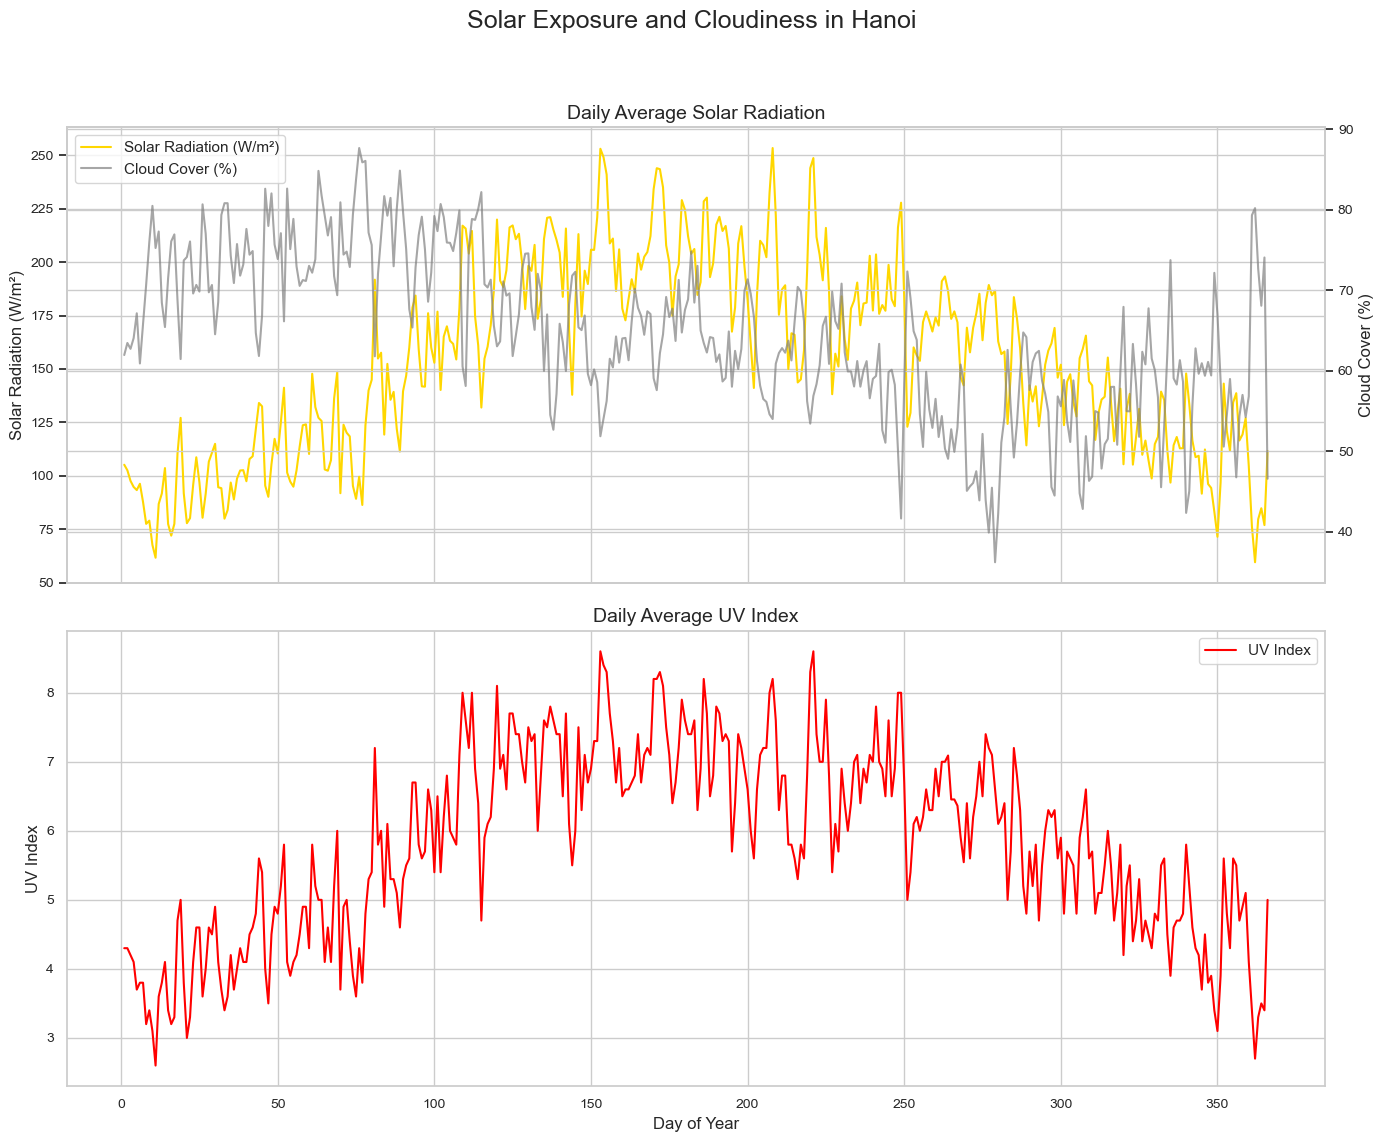

In [37]:
# Create a figure and a set of subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Plotting daily average solar radiation and cloud cover
daily_avg_solar_cloud = df.groupby('dayofyear')[['solarradiation', 'cloudcover']].mean()
axes[0].plot(daily_avg_solar_cloud.index, daily_avg_solar_cloud['solarradiation'], label='Solar Radiation (W/m²)', color='gold')
axes[0].set_ylabel('Solar Radiation (W/m²)')
axes[0].set_title('Daily Average Solar Radiation', fontsize=14)
ax_cloud = axes[0].twinx()
ax_cloud.plot(daily_avg_solar_cloud.index, daily_avg_solar_cloud['cloudcover'], label='Cloud Cover (%)', color='gray', alpha=0.7)
ax_cloud.set_ylabel('Cloud Cover (%)')
lines, labels = axes[0].get_legend_handles_labels()
lines2, labels2 = ax_cloud.get_legend_handles_labels()
ax_cloud.legend(lines + lines2, labels + labels2, loc='upper left')

# Plotting daily average UV index
daily_avg_uv = df.groupby('dayofyear')['uvindex'].mean()
axes[1].plot(daily_avg_uv.index, daily_avg_uv, label='UV Index', color='red')
axes[1].set_xlabel('Day of Year')
axes[1].set_ylabel('UV Index')
axes[1].set_title('Daily Average UV Index', fontsize=14)
axes[1].legend()

plt.suptitle('Solar Exposure and Cloudiness in Hanoi', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

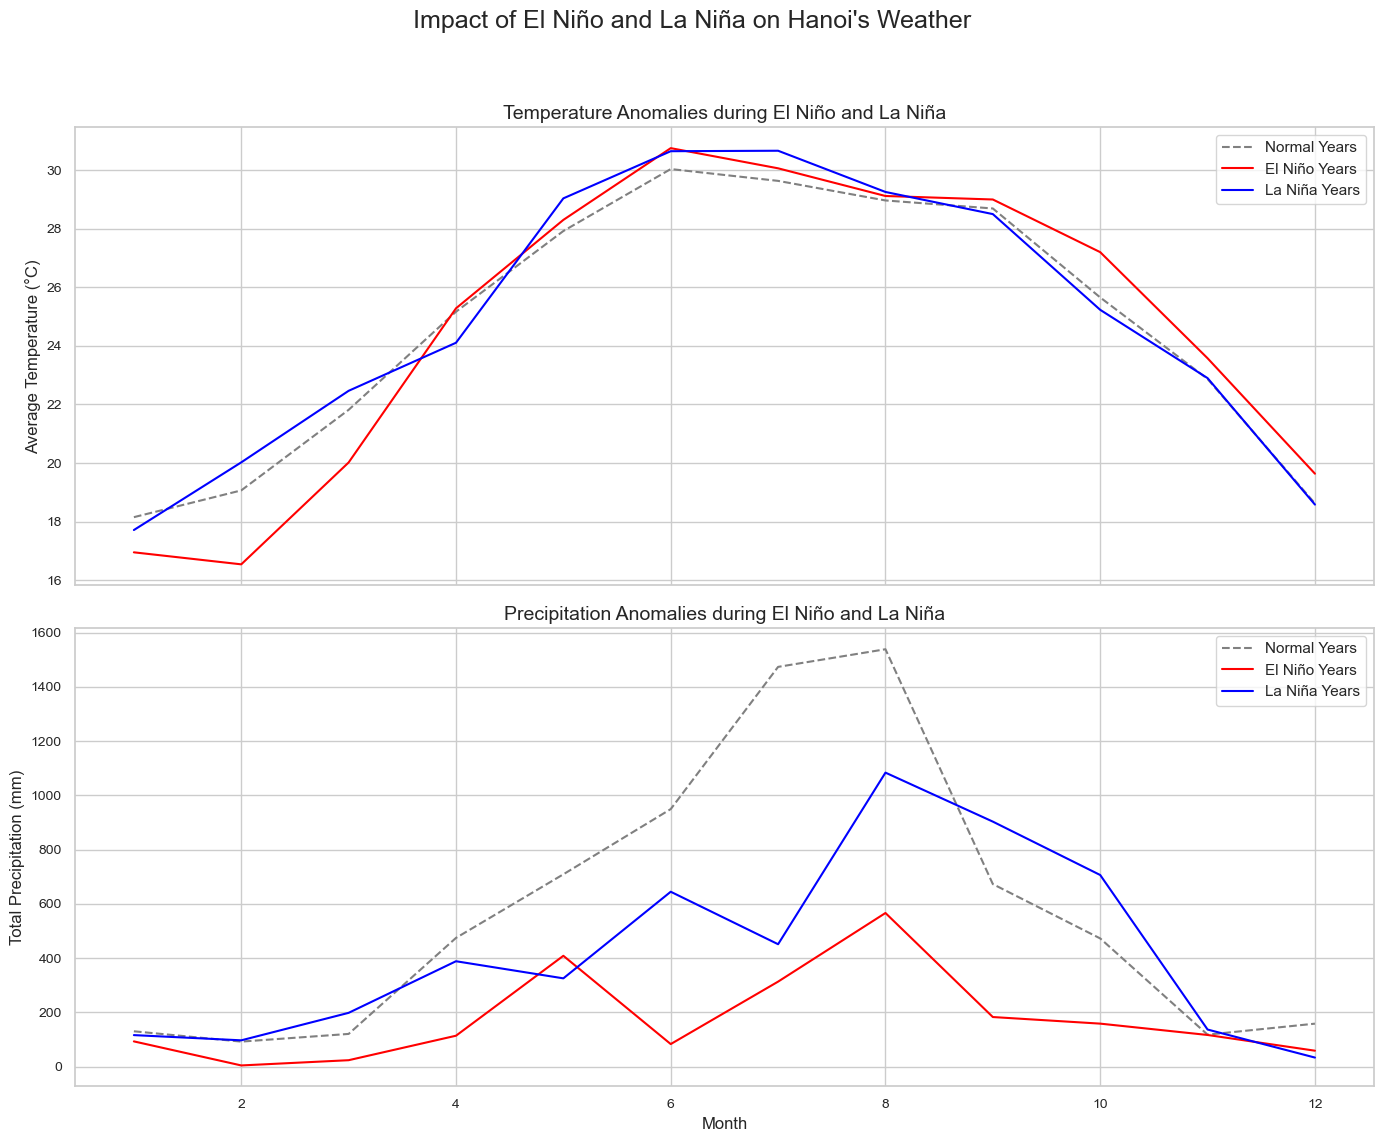

In [38]:
# Conceptual Example: You would need to define these year lists based on historical data.
el_nino_years = [2015, 2016] # Example years
la_nina_years = [2007, 2008, 2010, 2011, 2020, 2021, 2023] # Example years
normal_years = [2005, 2006, 2009, 2012, 2013, 2014, 2017, 2018, 2019, 2054, 2025] # Example years

# Filter the dataframe for these specific years
df_el_nino = df[df['year'].isin(el_nino_years)]
df_la_nina = df[df['year'].isin(la_nina_years)]
df_normal = df[df['year'].isin(normal_years)]

# Calculate monthly averages for each period
monthly_temp_el_nino = df_el_nino.groupby('month')['temp'].mean()
monthly_temp_la_nina = df_la_nina.groupby('month')['temp'].mean()
monthly_temp_normal = df_normal.groupby('month')['temp'].mean()

monthly_precip_el_nino = df_el_nino.groupby('month')['precip'].sum()
monthly_precip_la_nina = df_la_nina.groupby('month')['precip'].sum()
monthly_precip_normal = df_normal.groupby('month')['precip'].sum()


# Create a figure and a set of subplots
fig, axes = plt.subplots(2, 1, figsize=(14, 12), sharex=True)

# Plotting temperature anomalies
axes[0].plot(monthly_temp_normal.index, monthly_temp_normal.values, label='Normal Years', color='gray', linestyle='--')
axes[0].plot(monthly_temp_el_nino.index, monthly_temp_el_nino.values, label='El Niño Years', color='red')
axes[0].plot(monthly_temp_la_nina.index, monthly_temp_la_nina.values, label='La Niña Years', color='blue')
axes[0].set_ylabel('Average Temperature (°C)')
axes[0].set_title('Temperature Anomalies during El Niño and La Niña', fontsize=14)
axes[0].legend()
axes[0].grid(True)

# Plotting precipitation anomalies
axes[1].plot(monthly_precip_normal.index, monthly_precip_normal.values, label='Normal Years', color='gray', linestyle='--')
axes[1].plot(monthly_precip_el_nino.index, monthly_precip_el_nino.values, label='El Niño Years', color='red')
axes[1].plot(monthly_precip_la_nina.index, monthly_precip_la_nina.values, label='La Niña Years', color='blue')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Precipitation (mm)')
axes[1].set_title('Precipitation Anomalies during El Niño and La Niña', fontsize=14)
axes[1].legend()
axes[1].grid(True)


plt.suptitle('Impact of El Niño and La Niña on Hanoi\'s Weather', fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

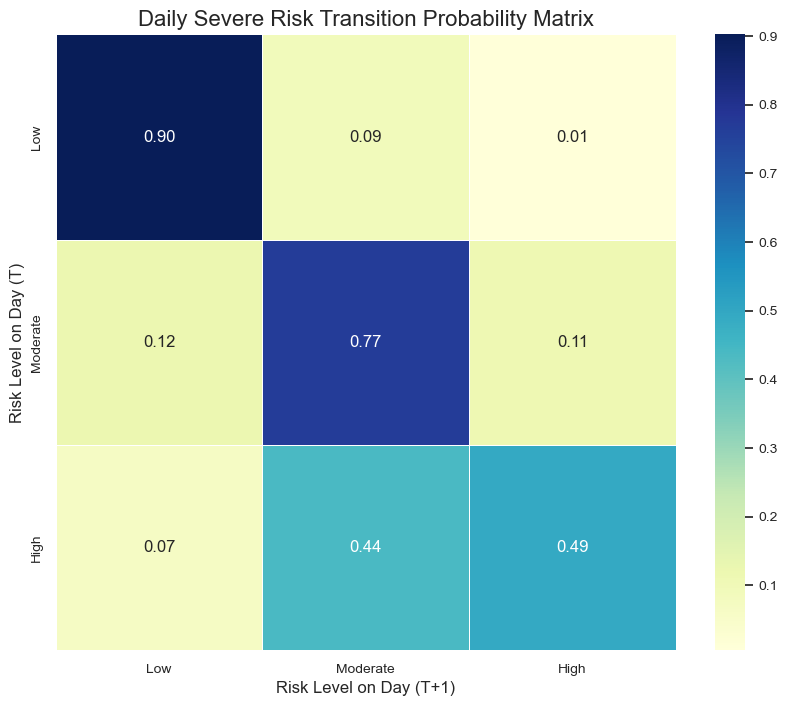

In [39]:
bins = [-1, 29, 69, 101]
labels = ['Low', 'Moderate', 'High']
df['risk_level'] = pd.cut(df['severerisk'], bins=bins, labels=labels)

# Calculate the transition probabilities
transition_counts = pd.crosstab(df['risk_level'], df['risk_level'].shift(-1))
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)

plt.figure(figsize=(10, 8))
sns.heatmap(transition_matrix, annot=True, cmap='YlGnBu', fmt='.2f', linewidths=.5)
plt.title('Daily Severe Risk Transition Probability Matrix', fontsize=16)
plt.xlabel('Risk Level on Day (T+1)')
plt.ylabel('Risk Level on Day (T)')
plt.show()

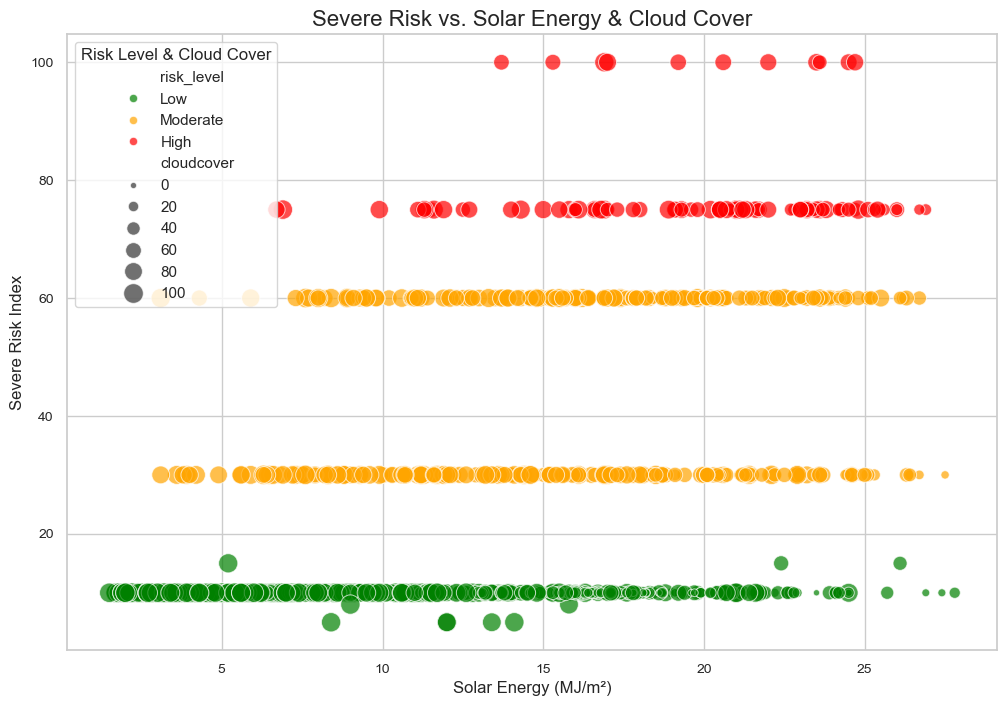

In [40]:
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df,
    x='solarenergy',
    y='severerisk',
    hue='risk_level',
    size='cloudcover',
    palette={'Low': 'green', 'Moderate': 'orange', 'High': 'red'},
    sizes=(20, 200),
    alpha=0.7
)
plt.title('Severe Risk vs. Solar Energy & Cloud Cover', fontsize=16)
plt.xlabel('Solar Energy (MJ/m²)')
plt.ylabel('Severe Risk Index')
plt.legend(title='Risk Level & Cloud Cover')
plt.grid(True)
plt.show()

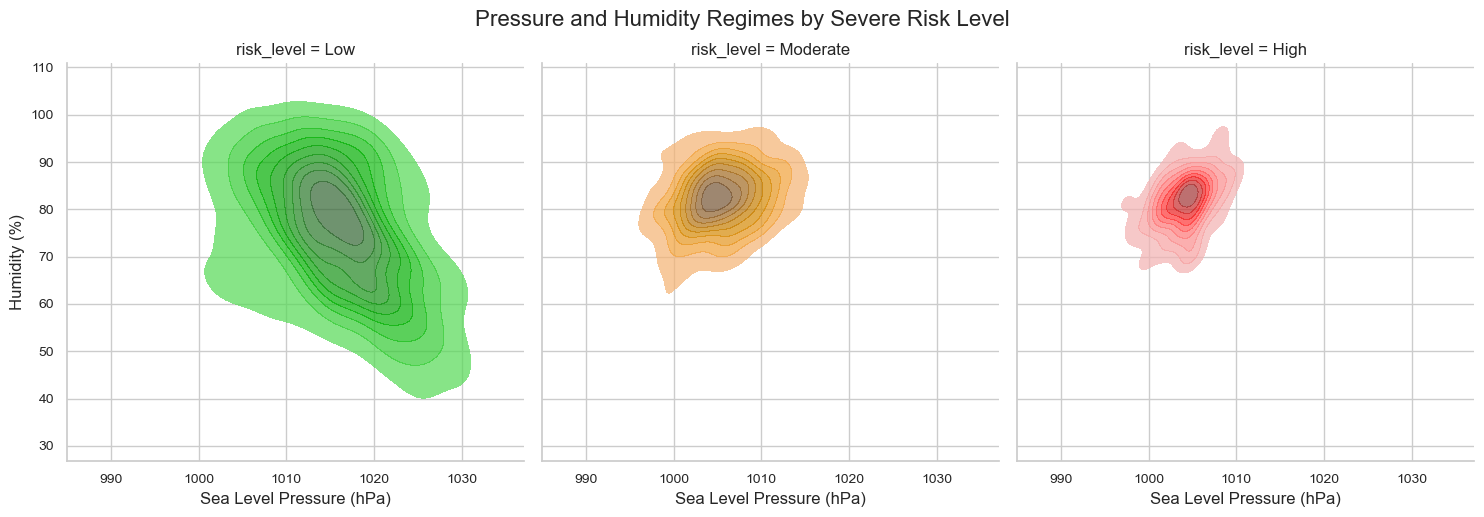

In [41]:
g = sns.FacetGrid(df, col="risk_level", hue="risk_level", col_wrap=3, height=5,
                  palette={'Low': 'green', 'Moderate': 'orange', 'High': 'red'})
g.map(sns.kdeplot, "sealevelpressure", "humidity", fill=True, alpha=0.7)
g.set_axis_labels("Sea Level Pressure (hPa)", "Humidity (%)")
g.fig.suptitle('Pressure and Humidity Regimes by Severe Risk Level', y=1.03, fontsize=16)
plt.show()

## Part 11 - Feature Engineering & Time Series Insights

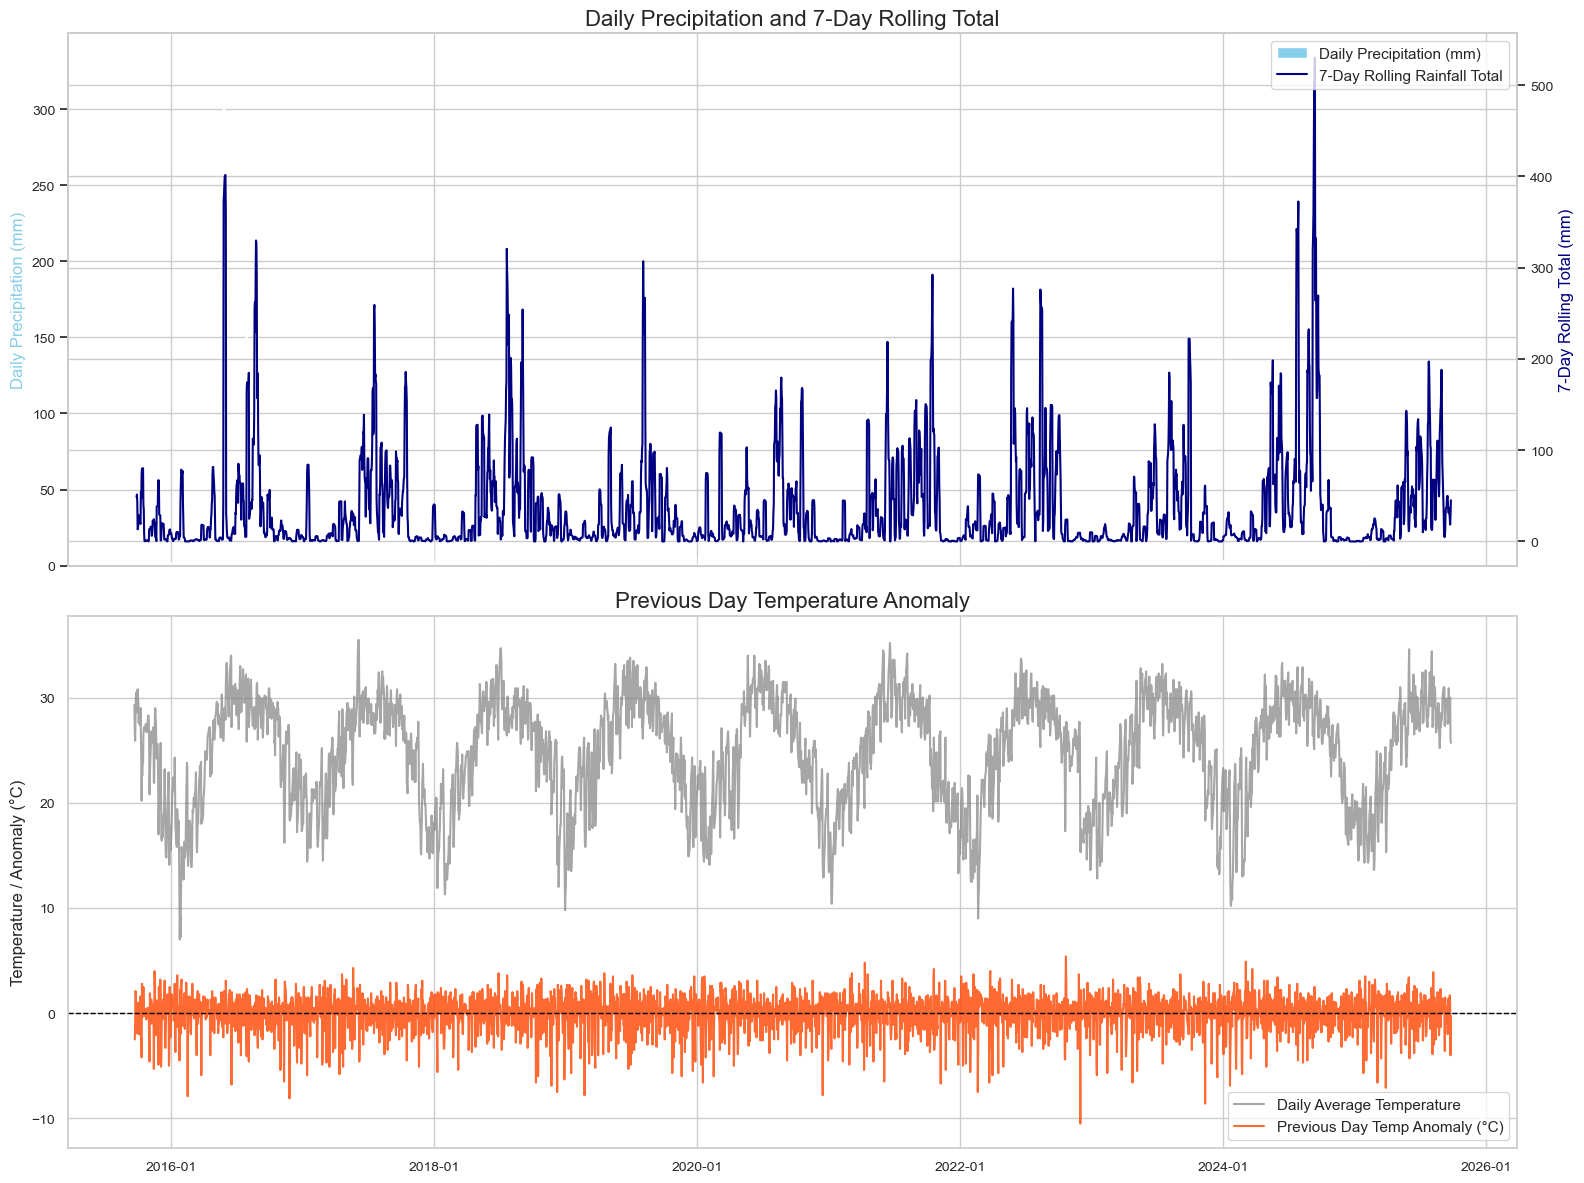

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# --- FIX: Ensure the DataFrame has a DatetimeIndex ---
# Convert the 'datetime' column to datetime objects, if not already done
df['datetime'] = pd.to_datetime(df['datetime'])
# Set the 'datetime' column as the index of the DataFrame
df.set_index('datetime', inplace=True)

# --- The rest of the code can now run correctly ---

# Engineer the features
# Resample to daily frequency to ensure no gaps. Use .agg to handle columns differently.
df_resampled = df.resample('D').agg({
    'temp': 'mean',
    'precip': 'sum'  # Use sum for daily precipitation
}).interpolate() # Interpolate to fill any missing daily means for temp

df_resampled.rename(columns={'precip': 'precip_total'}, inplace=True) # Rename for clarity

df_resampled['7_day_rain_total'] = df_resampled['precip_total'].rolling(window=7).sum()
df_resampled['prev_day_temp_anomaly'] = df_resampled['temp'].diff(1)

# --- Visualization ---
fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
sns.set_style("whitegrid")

# Plot 1: 7-Day Rolling Rainfall Total
ax1_precip = axes[0]
ax1_precip.bar(df_resampled.index, df_resampled['precip_total'], label='Daily Precipitation (mm)', color='skyblue', width=1.0)
ax1_precip.set_ylabel('Daily Precipitation (mm)', color='skyblue', fontsize=12)

ax1_rolling = ax1_precip.twinx()
ax1_rolling.plot(df_resampled.index, df_resampled['7_day_rain_total'], color='navy', label='7-Day Rolling Rainfall Total')
ax1_rolling.set_ylabel('7-Day Rolling Total (mm)', color='navy', fontsize=12)
axes[0].set_title('Daily Precipitation and 7-Day Rolling Total', fontsize=16)
# Manually create legends to avoid conflicts with twin axes
lines, labels = ax1_precip.get_legend_handles_labels()
lines2, labels2 = ax1_rolling.get_legend_handles_labels()
ax1_rolling.legend(lines + lines2, labels + labels2, loc='upper right')


# Plot 2: Previous Day Temperature Anomaly
axes[1].plot(df_resampled.index, df_resampled['temp'], label='Daily Average Temperature', color='gray', alpha=0.7)
axes[1].plot(df_resampled.index, df_resampled['prev_day_temp_anomaly'], label='Previous Day Temp Anomaly (°C)', color='orangered', alpha=0.8)
axes[1].set_title('Previous Day Temperature Anomaly', fontsize=16)
axes[1].set_ylabel('Temperature / Anomaly (°C)')
axes[1].axhline(0, color='black', linestyle='--', lw=1)
axes[1].legend()

# Formatting X-axis
plt.xlabel('Date', fontsize=12)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.tight_layout()
plt.show()

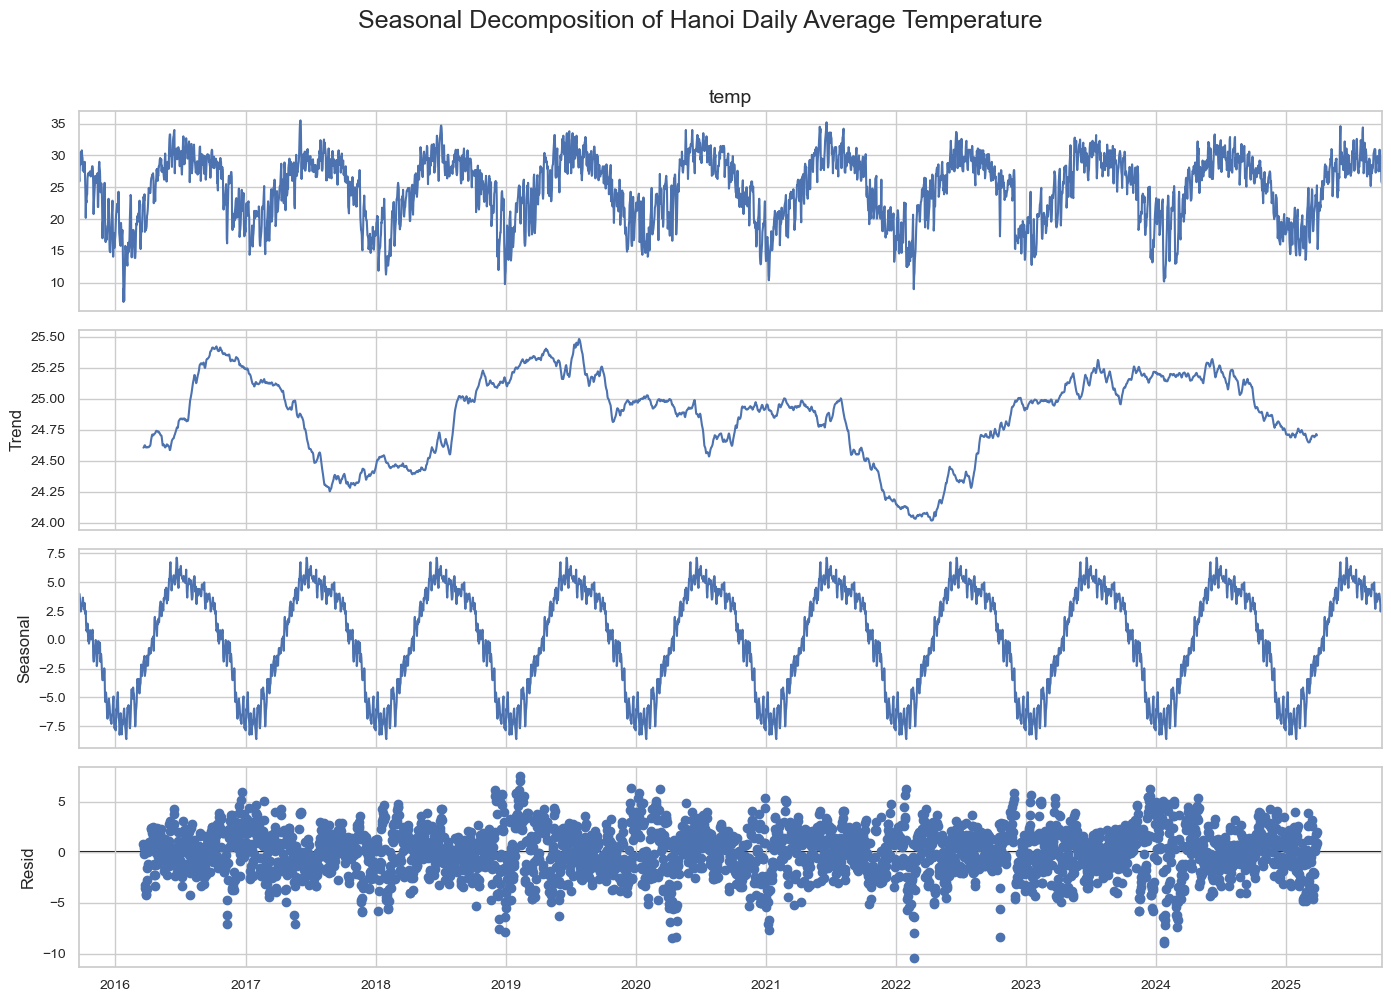

In [43]:
from statsmodels.tsa.seasonal import seasonal_decompose

# --- FIX: Ensure the DataFrame has a DatetimeIndex ---
# This is the same fix as before: convert the column and set it as the index.
# --- The rest of the code can now run correctly ---

# We need a consistently spaced time series with no missing values
temp_series = df['temp'].resample('D').mean().interpolate()

# Perform seasonal decomposition (additive model is suitable for temperature)
# The period is 365.25 to account for the yearly cycle
decomposition = seasonal_decompose(temp_series, model='additive', period=365)

# --- Visualization ---
fig = decomposition.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Seasonal Decomposition of Hanoi Daily Average Temperature', fontsize=18, y=1.0)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

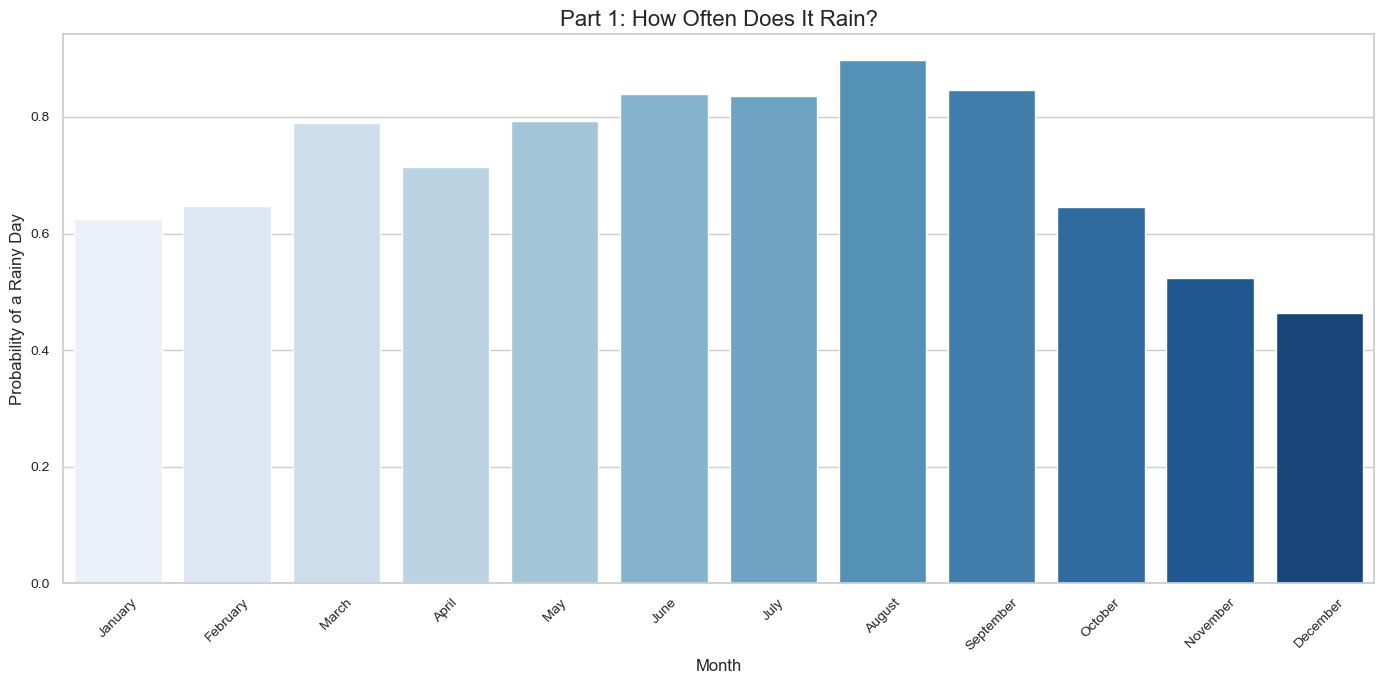

In [44]:
df_copy = df.copy()

# --- Data Preparation ---
# Resample to daily totals to determine rainy days
df_daily = df_copy.resample('D').agg({'precip': 'sum'}).copy()
df_daily['did_rain'] = (df_daily['precip'] > 0).astype(int)
df_daily['month_name'] = df_daily.index.month_name()

# Calculate the monthly probability of rain
monthly_rain_prob = df_daily.groupby('month_name')['did_rain'].mean()

# Reorder for chronological plotting
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_rain_prob = monthly_rain_prob.reindex(month_order)

# --- Visualization for Part 1 ---
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")

sns.barplot(x=monthly_rain_prob.index, y=monthly_rain_prob.values, palette='Blues')

plt.title('Part 1: How Often Does It Rain?', fontsize=16)
plt.ylabel('Probability of a Rainy Day', fontsize=12)
plt.xlabel('Month', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
